MediBot: Your AI-Powered Symptom Checker

#**MediBot: AI-Powered Symptom Checker**
**MediBot** is an **NLP-based**, **multi-turn** conversational medical assistant designed for educational purposes. It leverages a **React-style** interface powered by **LangChain agents** to handle dynamic interactions, providing **context-aware** responses while maintaining a **personalized conversation history** for each user. MediBot uses **RAG (Retrieval-Augmented Generation) with a FAISS engine** to retrieve relevant symptom-disease knowledge efficiently and accurately. The system is **multi-modal**, allowing users to input both **text and images** for richer diagnostic suggestions. By combining retrieval-based reasoning, generative NLP capabilities, and user-specific memory, MediBot offers an interactive, personalized, and contextually aware educational experience in medical reasoning.

**Human-AI Interaction**
Designed AI systems that interact naturally with humans.

In this project: the user communicates with MediBot through multi-turn conversations. The system responds contextually with explanations, severity scores, precautions, and recommendations.

Emphasizes usability, interpretability, and educational guidance—not just raw AI predictions.

Prompt Engineering: Carefully crafted prompts guide the LLM to produce accurate, structured, and safe responses, ensuring consistency in multi-turn dialogues and educational feedback.

**Context-Aware Agents**
AI agents remember past interactions and make decisions based on prior context.

In this project: MediBot uses persistent personalized memory and FAISS-based retrieval to maintain context across multiple turns, so follow-up questions (“Is it serious?”) are interpreted correctly.

Demonstrates advanced reasoning capabilities, including ReAct-style multi-step decision making in LangChain.

Prompt Engineering: Adaptive prompts dynamically incorporate context, FAISS retrieval results, and user history to improve relevance and safety of agent actions.

**Interactive Explainability:** MediBot provides step-by-step reasoning behind each recommendation, increasing user trust and educational value.

In [1]:
!pip install numpy pandas unidecode unidecode faiss-cpu sentence-transformers openai langchain langchain-community --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.6 MB/s eta 0:00:00


In [2]:
#imports basic Libs
import pandas as pd
import numpy as np
import re
import unidecode
import unicodedata

import re, unicodedata, unidecode, pandas as pd
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk

# Download NLTK resources once
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import faiss
import os

# For OpenAI chat/LLM
#from langchain.chat_models import ChatOpenAI
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.chat_models.openai import ChatOpenAI
from langchain.agents import Tool, initialize_agent, AgentType
from langchain.memory import ConversationBufferMemory
from langchain.prompts import SystemMessagePromptTemplate, ChatPromptTemplate
from langchain.schema import SystemMessage, HumanMessage
from langchain.agents import Tool
import itertools
from openai import OpenAI
from langchain.memory import ConversationSummaryMemory

# Dictionary to hold memory objects for each user
user_memory_store = {}
persistent_memory = None
user_sessionmemory_store = {}
session_memory = None

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Load the data

#Load Symptom Disease mapping dataset
disease_symptom_df = pd.read_csv('/content/disease_symptom.csv')
print("Sympton Disease mapping is loaded",disease_symptom_df.shape)
print(disease_symptom_df.columns)

#Load Sympton Severity dataset
symptom_severity_df = pd.read_csv('/content/symptom_severity.csv')
print("\nSympton Severity mapping is loaded",symptom_severity_df.shape)
print(symptom_severity_df.columns)

#Load Sympton Precaution dataset
disease_precaution_df = pd.read_csv('/content/disease_precaution.csv')
print("\nSympton Precaution mapping is loaded",disease_precaution_df.shape)
print(disease_precaution_df.columns)

#Load Disease Discription mapping
disease_description_df = pd.read_csv('/content/disease_description.csv')
print("\nDisease Discription mapping is loaded",disease_description_df.shape)
print(disease_description_df.columns)

Sympton Disease mapping is loaded (4920, 18)
Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='object')

Sympton Severity mapping is loaded (133, 2)
Index(['Symptom', 'weight'], dtype='object')

Sympton Precaution mapping is loaded (41, 5)
Index(['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3',
       'Precaution_4'],
      dtype='object')

Disease Discription mapping is loaded (41, 2)
Index(['Disease', 'Description'], dtype='object')


These datafrmaes shall be used by specialized AI agents:
* disease_df - Disease Diagnosis Agent – Predicts illnesses based on symptoms.
* severity_df - Symptom Severity Agent – Assesses urgency.
* description_df - Disease Description Agent – Provides explanations.
* precautions_df - Precaution Advisor Agent – Suggests preventive measures.

Some basic alignment rules:

Symptoms: disease_symptom_df → symptom_severity_df

Every symptom in disease_symptom_df must exist in symptom_severity_df.

Merge to get weight.

Diseases: disease_symptom_df → disease_description_df & disease_precaution_df

Every disease in disease_symptom_df should have a corresponding description and set of precautions.

In [5]:
disease_symptom_df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Link each disease with up to 17 possible symptoms.Provides disease → symptom associations.
Core knowledge base for the Disease Diagnosis Agent.Diagnosis Agent will query this table to find all diseases linked with given symptoms.

Convert all Symptom_i columns into a flat symptom list per disease during preprocessing.Flattened into {Disease: [symptom list]} for lookup & embedding into FAISS.
```
{
  "Disease": "Diabetes",
  "Symptoms": ["excessive thirst", "frequent urination", "fatigue", ...]
}
```

In [6]:
symptom_severity_df.head()

,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


Each symptom has a severity/urgency score. Indicates how critical/urgent a symptom is.
Input for the Symptom Severity Agent.Symptom Severity Agent retrieves the weight of each symptom mentioned by user. Severity aggregation helps classify urgency levels (mild/moderate/severe).Useful for advising when to seek immediate medical help.

Aggregate severity → assign an urgency class (e.g., 0–2 = mild, 3–6 = moderate, >6 = severe).


In [7]:
disease_description_df.head()

,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...


Provide a clear explanation of the disease.Provides textual explanations (overview, causes, risk factors).
Consumed by the Disease Description Agent.Reformatted into easy-to-understand natural language for chatbot replies.Disease Description Agent retrieves and reformats description into user-friendly text.

Can be expanded later to include Causes, Risk_Factors, Treatment if available.

In [8]:
disease_precaution_df.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


Recommend preventive/self-care measures.Suggests lifestyle changes, preventive care, and self-management tips.
Accessed by the Precaution Advisor Agent.
Precaution Advisor Agent fetches list of precautions for diagnosed disease.

Preprocess into structured JSON-like array for easier retrieval.

Example:
```
{
  "Disease": "Hypertension",
  "Precautions": ["Reduce salt intake", "Exercise regularly", "Avoid stress", "Take prescribed medication"]
}

```

Together, these 4 datasets cover the entire workflow:
* Diagnose → Check severity → Explain → Suggest precautions.
* The FAISS layer will enable semantic search across symptoms, while severity/precaution datasets provide structured lookups.

**Example User Flow**

User: "I feel feverish and have a dry cough"

ReAct → Diagnosis Agent → likely diseases: Flu, COVID-19

Severity Agent → "Moderate"

Description Agent → Explain Flu & COVID-19 differences

Precaution Agent → Rest, hydration, mask, consult doctor if worsening

MediBot → "It looks like you may have Flu or COVID-19. Your symptoms are moderate. Here’s what you should do..."

**High-Level Workflow**

* User enters symptom in natural language.

* NLU converts text → structured symptom vector.

* ReAct Controller decides which agent(s) to call.

* Disease Diagnosis Agent queries FAISS → probable diseases.

* Symptom Severity Agent scores urgency.

* Disease Description Agent fetches simplified explanation.

* Precaution Advisor Agent fetches recommendations.

* Controller aggregates responses → sends back to user.

* Conversation memory updated.

##**Data Review & Cleaning** ##

Before agents can work, I shall normalize & structure the CSVs:
* Identify missing values, duplicates, outliers
* Handle nulls and duplicates
* Numeric outlier handling (IQR)
* Textual outlier handling (short/long/empty entries)
* Convert categorical fields into suitable formats (for example, symptoms as lists)
* Create embeddings for symptoms/disease combinations using a sentence embedding model for FAISS


In [9]:
# --- Normalization helpers ---
lemmatizer = WordNetLemmatizer()

# Base stopwords
base_stopwords = set(stopwords.words("english"))

# Critical words must KEEP (negations etc.)
medical_keep_words = {"no", "not", "without", "none", "nor", "against"}

# Safe stopword list (preserves negations)
safe_stopwords = base_stopwords - medical_keep_words

# Common medical abbreviation mapping
ABBR_MAP = {
    "htn": "hypertension",
    "ht": "hypertension",
    "dm": "diabetes",
    "cad": "coronary artery disease",
    "mi": "myocardial infarction",
    "bp": "blood pressure",
    "copd": "chronic obstructive pulmonary disease",
    "ckd": "chronic kidney disease",
}


def normalize_text_advanced(text, max_len=None):
    """
    Cleans and preprocesses text for medical NLP tasks:
    - Lowercases, removes accents/punctuation
    - Maps medical abbreviations (e.g. HTN → hypertension)
    - Keeps negations (no, not, without, none)
    - Removes safe stopwords
    - Applies lemmatization
    - Deduplicates tokens
    - Truncates if needed
    """
    # Handle missing or invalid input
    if pd.isna(text) or str(text).strip().lower() in ["", "nan", "none", "<na>"]:
        return "unknown"

    # Convert to string
    text = str(text)

    # Unicode normalization + accent removal
    text = unidecode.unidecode(text)
    text = ''.join(ch for ch in unicodedata.normalize('NFKC', text)
                   if not unicodedata.combining(ch))

    # Lowercase
    text = text.lower()

    # Replace hyphens/underscores with spaces
    text = text.replace("-", " ").replace("_", " ")

    # Remove non-alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = text.split()

    # Map medical abbreviations to full forms
    tokens = [ABBR_MAP.get(w, w) for w in tokens]

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in safe_stopwords]

    # Deduplicate tokens while preserving order
    tokens = list(dict.fromkeys(tokens))

    # Rebuild string
    text = " ".join(tokens)

    # Optional truncation
    if max_len is not None and len(text) > max_len:
        text = text[:max_len] + "..."

    return text

# -------------------------
# 1. Disease-Symptom Dataset (Wide → Long after cleaning)
# -------------------------

# Identify symptom columns
symptom_cols = [col for col in disease_symptom_df.columns if col.startswith("Symptom")]

# Drop rows where all symptom columns are NaN
disease_symptom_df = disease_symptom_df.dropna(subset=symptom_cols, how='all')

# Apply text normalization to all symptom columns
for col in symptom_cols:
    disease_symptom_df[col] = disease_symptom_df[col].apply(
        lambda x: normalize_text_advanced(str(x)) if pd.notna(x) else None
    )

# Optional: normalize Disease column as well
disease_symptom_df["Disease"] = disease_symptom_df["Disease"].apply(
    lambda x: normalize_text_advanced(str(x)) if pd.notna(x) else None
)

# -------------------------
# 2. Symptom Severity Dataset
# -------------------------
symptom_severity_df = symptom_severity_df.dropna(subset=["Symptom"])
symptom_severity_df["Symptom"] = symptom_severity_df["Symptom"].apply(normalize_text_advanced)

# -------------------------
# 3. Disease Precautions Dataset (KEEP WIDE)
# -------------------------
disease_precaution_df = disease_precaution_df.dropna(subset=["Disease"])
for col in disease_precaution_df.columns:
    disease_precaution_df[col] = disease_precaution_df[col].apply(normalize_text_advanced)

# -------------------------
# 4. Disease Descriptions Dataset
# -------------------------
disease_description_df = disease_description_df.dropna(subset=["Disease"])
disease_description_df["Disease"] = disease_description_df["Disease"].apply(normalize_text_advanced)
disease_description_df["Description"] = disease_description_df["Description"].apply(
    lambda x: str(x).strip() if pd.notna(x) else None
)


In [10]:
# -------------------------
# Missing values
# -------------------------
print("\n=== Missing Values ===")
print("Disease-Symptom:", disease_symptom_df.isna().sum())
print("Severity:", symptom_severity_df.isna().sum())
print("Precautions:", disease_precaution_df.isna().sum())
print("Descriptions:", disease_description_df.isna().sum())

# -------------------------
# Duplicates
# -------------------------
print("\n=== Duplicates ===")
print("Disease-Symptom duplicates:", disease_symptom_df.duplicated().sum())
print("Severity duplicates:", symptom_severity_df.duplicated().sum())
print("Precautions duplicates:", disease_precaution_df.duplicated().sum())
print("Descriptions duplicates:", disease_description_df.duplicated().sum())



=== Missing Values ===
Disease-Symptom: Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64
Severity: Symptom    0
weight     0
dtype: int64
Precautions: Disease         0
Precaution_1    0
Precaution_2    0
Precaution_3    0
Precaution_4    0
dtype: int64
Descriptions: Disease        0
Description    0
dtype: int64

=== Duplicates ===
Disease-Symptom duplicates: 4616
Severity duplicates: 0
Precautions duplicates: 0
Descriptions duplicates: 0


In [11]:

# -------------------------
# Numeric Outliers (IQR method on 'weight')
# -------------------------
Q1 = symptom_severity_df['weight'].quantile(0.25)
Q3 = symptom_severity_df['weight'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = symptom_severity_df[
    (symptom_severity_df['weight'] < lower_bound) | (symptom_severity_df['weight'] > upper_bound)
]

print("\n=== Symptom Severity Outliers (IQR) ===")
print(outliers)

# -------------------------
# Outlier check (IQR on weight)
# -------------------------
Q1 = symptom_severity_df['weight'].quantile(0.25)
Q3 = symptom_severity_df['weight'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = symptom_severity_df[
    (symptom_severity_df['weight'] < lower_bound) | (symptom_severity_df['weight'] > upper_bound)
]

print("\n=== Remaining Outliers in Symptom Severity (review manually) ===")
print(outliers)


print("\n After cleaning: shapes")
print("Disease-Symptom:", disease_symptom_df.shape)
print("Severity:", symptom_severity_df.shape)
print("Precautions:", disease_precaution_df.shape)
print("Descriptions:", disease_description_df.shape)




=== Symptom Severity Outliers (IQR) ===
Empty DataFrame
Columns: [Symptom, weight]
Index: []

=== Remaining Outliers in Symptom Severity (review manually) ===
Empty DataFrame
Columns: [Symptom, weight]
Index: []

 After cleaning: shapes
Disease-Symptom: (4920, 18)
Severity: (133, 2)
Precautions: (41, 5)
Descriptions: (41, 2)


In [12]:
# --- Numeric imputation ---
median_weight = symptom_severity_df['weight'].median()
symptom_severity_df['weight'] = symptom_severity_df['weight'].fillna(median_weight)

# --- Textual missing value imputation ---
# Identify all symptom columns
symptom_cols = [col for col in disease_symptom_df.columns if col.startswith("Symptom")]
# Fill NaNs with 'unknown'
disease_symptom_df[symptom_cols] = disease_symptom_df[symptom_cols].fillna('unknown')

disease_description_df['Description'] = disease_description_df['Description'].fillna('no description')
for col in ['Precaution_1','Precaution_2','Precaution_3','Precaution_4']:
    disease_precaution_df[col] = disease_precaution_df[col].fillna('no precaution')

# --- Drop duplicates only ---
disease_symptom_df = disease_symptom_df.drop_duplicates()
symptom_severity_df = symptom_severity_df.drop_duplicates()
disease_precaution_df = disease_precaution_df.drop_duplicates()
disease_description_df = disease_description_df.drop_duplicates()

# --- Numeric outlier capping (1.5×IQR) ---
Q1 = symptom_severity_df['weight'].quantile(0.25)
Q3 = symptom_severity_df['weight'].quantile(0.75)
IQR = Q3 - Q1
symptom_severity_df['weight'] = symptom_severity_df['weight'].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)


In [13]:
# Verification
print("Remaining real NaNs:", {
    "disease_symptom_df": disease_symptom_df.isna().sum().sum(),
    "symptom_severity_df": symptom_severity_df['Symptom'].isna().sum(),
    "disease_description_df": disease_description_df.isna().sum().sum(),
    "disease_precaution_df": disease_precaution_df.isna().sum().sum()
})
# Verification
print("Remaining Duplicates:", {
    "disease_symptom_df": disease_symptom_df.duplicated().sum(),
    "symptom_severity_df": symptom_severity_df.duplicated().sum(),
    "disease_description_df": disease_precaution_df.duplicated().sum(),
    "disease_precaution_df": disease_description_df.duplicated().sum()
})

Remaining real NaNs: {'disease_symptom_df': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}
Remaining Duplicates: {'disease_symptom_df': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}


##**Data Pre-Processing**

Now missing values and inconsistencies are handled,making the datasets ready for normalization, consistent for FAISS-based retrieval and multi-agent reasoning.

**Embedding Similarity so detect multi-word synonyms**
1. Collect all unique terms (diseases + symptoms) from all datasets.
2. Generate embeddings using a sentence embedding model (OpenAI embeddings or 3 sentence-transformers).
4. Compute cosine similarity between all pairs.
5. Define a threshold (e.g., 0.85) above which two terms are considered synonyms.
6. Build canonical mapping:
7. Pick the most frequent or longest term as canonical.
8. Map all semantically similar terms to it.
9. Apply the synonym dictionary across all datasets.

In [14]:
#melt
# -------------------------
# 1. Symptom-Disease Mapping
# -------------------------
# This cell converts the disease-symptom dataset from wide to long format:
# 1. Identifies all symptom columns (Symptom_1, Symptom_2, …).
# 2. Melts the wide dataframe into long format, creating one row per Disease-Symptom pair.
# 3. Drops missing symptom entries and normalizes both Disease and Symptom text.
# 4. Merges symptom severity weights to include importance/weight for each symptom.
# Result: a clean, canonical long-format mapping ready for downstream processing.

symptom_cols = [col for col in disease_symptom_df.columns if col.startswith("Symptom")]

# Wide → long
disease_symptom_long = disease_symptom_df.melt(
    id_vars=["Disease"],
    value_vars=symptom_cols,
    var_name="Symptom_num",
    value_name="Symptom"
).dropna(subset=["Symptom"])

# Drop nulls and normalize
disease_symptom_long = disease_symptom_long.dropna(subset=["Symptom"])
disease_symptom_long["Disease"] = disease_symptom_long["Disease"].apply(normalize_text_advanced)
disease_symptom_long["Symptom"] = disease_symptom_long["Symptom"].apply(normalize_text_advanced)

# Merge severity weights into long form mapping
disease_symptom_long = disease_symptom_long.merge(
    symptom_severity_df, on="Symptom", how="left"
)
# fill any remaining NaNs
disease_symptom_long['weight'] = disease_symptom_long['weight'].fillna(0.0)

# Drop rows with unknown symptoms
disease_symptom_long = disease_symptom_long[disease_symptom_long['Symptom'] != 'unknown']

#Drop Duplicates
disease_symptom_long = disease_symptom_long.drop_duplicates(subset=['Disease', 'Symptom'])
disease_symptom_long = disease_symptom_long.reset_index(drop=True)


In [15]:
# Verification
print("Remaining real NaNs:", {
    "disease_symptom_long": disease_symptom_long.isna().sum().sum(),
    "symptom_severity_df": symptom_severity_df.isna().sum().sum(),
    "disease_description_df": disease_description_df.isna().sum().sum(),
    "disease_precaution_df": disease_precaution_df.isna().sum().sum()
})
# Verification
print("Remaining Duplicates:", {
    "disease_symptom_long": disease_symptom_long.duplicated(subset=['Disease', 'Symptom']).sum(),
    "symptom_severity_df": symptom_severity_df.duplicated().sum(),
    "disease_description_df": disease_precaution_df.duplicated().sum(),
    "disease_precaution_df": disease_description_df.duplicated().sum()
})

Remaining real NaNs: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}
Remaining Duplicates: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}


Best practice step for robust AI pipelines is by converting diseases and symptoms into stable IDs:

Embeddings, FAISS indices, and downstream ML models reference consistent numeric IDs rather than variable-length text.

Canonical mapping ensures that multiple variants of the same term share the same ID.

IDs make joins, lookups, and logging much safer and faster.

**Benefits**
* Stable references – “chest pain” always maps to the same S001 ID.
* FAISS / embeddings – numeric IDs can be used for indexing, logging, and lookups.
* Downstream ML models – easier to encode categorical features consistently.
* Joins across datasets – ID-based joins are faster and safer than text-based joins.

All datasets are canonical, normalized, and ID-encoded, which means they are now fully ready for FAISS embeddings, vector search, and multi-agent reasoning.

In [16]:
# ===============================
# Semantic Canonical Mapping
# ===============================
# This step ensures consistent naming of diseases and symptoms across all datasets.
# It performs the following actions:
# 1. Assigns stable, unique IDs to each disease and symptom.
# 2. Generates semantic embeddings for every term using a SentenceTransformer model.
# 3. Detects semantically similar terms (cosine similarity ≥ 0.85) — e.g., "stomach ache" ≈ "abdominal pain".
# 4. Maps all similar terms to a single canonical (standardized) representation.
# 5. Updates all dataframes so each disease and symptom has a unified, canonical label.
#
# This step is especially useful before FAISS indexing or semantic search,
# as it prevents duplication and improves retrieval accuracy.

def build_canonical_map(unique_terms, embeddings, threshold=0.85):
    canonical_map = {}
    for i, term in enumerate(unique_terms):
        if term in canonical_map:
            continue
        sims = cosine_similarity([embeddings[i]], embeddings)[0]
        similar_idx = np.where(sims >= threshold)[0]
        for idx in similar_idx:
            canonical_map[unique_terms[idx]] = term
    return canonical_map

# Combine all terms for mapping
all_symptoms = pd.Series(list(disease_symptom_long['Symptom']) + list(symptom_severity_df['Symptom'])).unique()
all_diseases = pd.Series(list(disease_symptom_long['Disease']) + list(disease_description_df['Disease']) + list(disease_precaution_df['Disease'])).unique()

# Stable ID DataFrames
unique_symptoms_df = pd.DataFrame({'Symptom_ID': [f"S{i+1:03d}" for i in range(len(all_symptoms))], 'Symptom': all_symptoms})
unique_diseases_df = pd.DataFrame({'Disease_ID': [f"D{i+1:03d}" for i in range(len(all_diseases))], 'Disease': all_diseases})

# Compute embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
symptom_embeddings = model.encode(unique_symptoms_df['Symptom'].tolist(), convert_to_numpy=True)
disease_embeddings = model.encode(unique_diseases_df['Disease'].tolist(), convert_to_numpy=True)
symptom_embeddings /= np.linalg.norm(symptom_embeddings, axis=1, keepdims=True)
disease_embeddings /= np.linalg.norm(disease_embeddings, axis=1, keepdims=True)

# Build canonical maps
canonical_symptom_map = build_canonical_map(unique_symptoms_df['Symptom'].tolist(), symptom_embeddings)
canonical_disease_map = build_canonical_map(unique_diseases_df['Disease'].tolist(), disease_embeddings)

# Apply canonical maps
for df, col, cmap in [
    (disease_symptom_long, 'Symptom', canonical_symptom_map),
    (symptom_severity_df, 'Symptom', canonical_symptom_map),
    (disease_symptom_long, 'Disease', canonical_disease_map),
    (disease_description_df, 'Disease', canonical_disease_map),
    (disease_precaution_df, 'Disease', canonical_disease_map)
]:
    df[col] = df[col].map(lambda x: cmap.get(x, 'unknown'))

# Map Symptom IDs
symptom_id_map = dict(zip(unique_symptoms_df['Symptom'], unique_symptoms_df['Symptom_ID']))
for df in [disease_symptom_long, symptom_severity_df]:
    df['Symptom_ID'] = df['Symptom'].map(lambda x: symptom_id_map.get(x, 'unknown'))
    symptom_severity_df = symptom_severity_df.drop_duplicates(subset=['Symptom'])

# Map Disease IDs
disease_id_map = dict(zip(unique_diseases_df['Disease'], unique_diseases_df['Disease_ID']))
for df in [disease_symptom_long, disease_description_df, disease_precaution_df]:
    df['Disease_ID'] = df['Disease'].map(lambda x: disease_id_map.get(x, 'unknown'))
    disease_symptom_long = disease_symptom_long.drop_duplicates(subset=['Disease_ID','Symptom_ID'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [17]:
reverse_map = {}
for k, v in canonical_disease_map.items():
    reverse_map.setdefault(v, []).append(k)

for canonical, variants in list(reverse_map.items()): #[:1250]
    print(f"{canonical}: {variants}")

fungal infection: ['fungal infection']
allergy: ['allergy']
gerd: ['gerd']
chronic cholestasis: ['chronic cholestasis']
drug reaction: ['drug reaction']
peptic ulcer diseae: ['peptic ulcer diseae']
aid: ['aid']
diabetes: ['diabetes']
gastroenteritis: ['gastroenteritis']
bronchial asthma: ['bronchial asthma']
hypertension: ['hypertension']
migraine: ['migraine']
cervical spondylosis: ['cervical spondylosis']
paralysis brain hemorrhage: ['paralysis brain hemorrhage']
jaundice: ['jaundice']
malaria: ['malaria']
chicken pox: ['chicken pox']
dengue: ['dengue']
typhoid: ['typhoid']
hepatitis: ['hepatitis']
hepatitis b: ['hepatitis b']
hepatitis c: ['hepatitis c']
hepatitis e: ['hepatitis e']
alcoholic hepatitis: ['alcoholic hepatitis']
tuberculosis: ['tuberculosis']
common cold: ['common cold']
pneumonia: ['pneumonia']
dimorphic hemmorhoids pile: ['dimorphic hemmorhoids pile', 'dimorphic hemorrhoid pile']
heart attack: ['heart attack']
varicose vein: ['varicose vein']
hypothyroidism: ['hypot

In [18]:
# Verification
print("Remaining real NaNs:", {
    "disease_symptom_long": disease_symptom_long.isna().sum().sum(),
    "symptom_severity_df": symptom_severity_df.isna().sum().sum(),
    "disease_description_df": disease_description_df.isna().sum().sum(),
    "disease_precaution_df": disease_precaution_df.isna().sum().sum()
})
# Verification
print("Remaining Duplicates:", {
    "disease_symptom_long": disease_symptom_long.duplicated(subset=['Disease', 'Symptom']).sum(),
    "symptom_severity_df": symptom_severity_df.duplicated().sum(),
    "disease_description_df": disease_precaution_df.duplicated().sum(),
    "disease_precaution_df": disease_description_df.duplicated().sum()
})


Remaining real NaNs: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}
Remaining Duplicates: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}


In [19]:
# Collect all unique symptoms from the long-form mapping
all_symptoms_mapping = set(disease_symptom_long['Symptom'])

# Collect all symptoms from the severity dataframe
all_symptoms_severity = set(symptom_severity_df['Symptom'])

# Find symptoms that exist in mapping but not in severity table
missing_in_severity = all_symptoms_mapping - all_symptoms_severity

print(f"Missing symptoms in severity table: {len(missing_in_severity)}")
print(missing_in_severity)

Missing symptoms in severity table: 1
{'foul smell urine'}


In [20]:
mapping_diseases = set(disease_symptom_long["Disease"])
desc_diseases = set(disease_description_df["Disease"])
missing_desc = mapping_diseases - desc_diseases
print(missing_desc)
prec_diseases = set(disease_precaution_df["Disease"])
missing_prec = mapping_diseases - prec_diseases
print(missing_prec)

set()
set()


In [21]:
# ===============================
# Encoding / Categorization - Final Canonicalization and Stable ID Assignment
# ===============================
# This cell finalizes the canonicalization process by:
# 1. Assigning stable unique IDs to all canonical diseases and symptoms.
# 2. Mapping these IDs across all relevant dataframes for consistency.
# 3. Reordering columns for clarity and standard structure.
# 4. Performing assertions to ensure that all diseases and symptoms are present in the canonical lists.
# 5. Printing a quick summary to verify that canonical mapping and ID assignment were applied successfully.
# ===============================
all_symptoms = pd.Series(list(disease_symptom_long['Symptom']) + list(symptom_severity_df['Symptom'])).unique()
all_diseases = pd.Series(list(disease_symptom_long['Disease']) + list(disease_description_df['Disease']) + list(disease_precaution_df['Disease'])).unique()

unique_symptoms_df = pd.DataFrame({'Symptom_ID': [f"S{i+1:03d}" for i in range(len(all_symptoms))], 'Symptom': all_symptoms})
unique_diseases_df = pd.DataFrame({'Disease_ID': [f"D{i+1:03d}" for i in range(len(all_diseases))], 'Disease': all_diseases})


# Enumerate over the 'Disease' and 'Symptom' columns
disease_id_map = {d: f"D{str(i+1).zfill(3)}" for i, d in enumerate(unique_diseases_df['Disease'])}
symptom_id_map = {s: f"S{str(i+1).zfill(3)}" for i, s in enumerate(unique_symptoms_df['Symptom'])}


# Apply IDs
disease_symptom_long['Disease_ID'] = disease_symptom_long['Disease'].map(disease_id_map)
disease_symptom_long['Symptom_ID'] = disease_symptom_long['Symptom'].map(symptom_id_map)
symptom_severity_df ['Symptom_ID'] = symptom_severity_df ['Symptom'].map(symptom_id_map)
disease_description_df['Disease_ID'] = disease_description_df['Disease'].map(disease_id_map)
disease_precaution_df['Disease_ID'] = disease_precaution_df['Disease'].map(disease_id_map)

# Reorder columns
disease_symptom_long = disease_symptom_long[['Disease_ID','Disease','Symptom_ID','Symptom','weight']]
symptom_severity_df  = symptom_severity_df [['Symptom_ID','Symptom','weight']]
disease_description_df = disease_description_df[['Disease_ID','Disease','Description']]
disease_precaution_df = disease_precaution_df[['Disease_ID','Disease','Precaution_1','Precaution_2','Precaution_3','Precaution_4']]


    # Symptoms
assert all(symptom_severity_df ['Symptom'].isin(unique_symptoms_df['Symptom'])), \
    "Some symptoms in symptom_severity_df  are missing in canonical list"

assert all(disease_symptom_long['Symptom'].isin(unique_symptoms_df['Symptom'])), \
    "Some symptoms in disease_symptom_long are missing in canonical list"

# Diseases
assert all(disease_description_df['Disease'].isin(unique_diseases_df['Disease'])), \
    "Some diseases in disease_description_df are missing in canonical list"

assert all(disease_precaution_df['Disease'].isin(unique_diseases_df['Disease'])), \
    "Some diseases in precautions_df are missing in canonical list"

# Quick check
print("Canonical mapping and stable IDs applied successfully!")
print("Symptom-Disease mapping rows:", disease_symptom_long.shape)
print("Severity rows:", symptom_severity_df .shape)
print("Description rows:", disease_description_df.shape)
print("Precautions rows:", disease_precaution_df.shape)

Canonical mapping and stable IDs applied successfully!
Symptom-Disease mapping rows: (312, 5)
Severity rows: (131, 3)
Description rows: (41, 3)
Precautions rows: (41, 6)


In [22]:
# Verification
print("Remaining real NaNs:", {
    "disease_symptom_long": disease_symptom_long.isna().sum().sum(),
    "symptom_severity_df": symptom_severity_df.isna().sum().sum(),
    "disease_description_df": disease_description_df.isna().sum().sum(),
    "disease_precaution_df": disease_precaution_df.isna().sum().sum()
})
# Verification
print("Remaining Duplicates:", {
    "disease_symptom_long": disease_symptom_long.duplicated(subset=['Disease', 'Symptom']).sum(),
    "symptom_severity_df": symptom_severity_df.duplicated().sum(),
    "disease_description_df": disease_precaution_df.duplicated().sum(),
    "disease_precaution_df": disease_description_df.duplicated().sum()
})


Remaining real NaNs: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}
Remaining Duplicates: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}


In [23]:
# Final Check - after doing some ad-hoc test, taking cases
# solution for this - disease_symptom_long[disease_symptom_long['weight'].isna()]
#Check anf Fix for remaining NAn for Weight
# Merge with symptom_severity_df
disease_symptom_long = disease_symptom_long.drop(columns=['weight']).merge(
    symptom_severity_df[['Symptom_ID','weight']],
    on='Symptom_ID',
    how='left'
)

# Replace non-numeric or NaN with median
median_weight = symptom_severity_df['weight'].median()

# Safe numeric conversion: non-numeric → NaN → fill with median
disease_symptom_long['weight'] = pd.to_numeric(disease_symptom_long['weight'], errors='coerce')
disease_symptom_long['weight'] = disease_symptom_long['weight'].fillna(median_weight)

# Check
print("Remaining NaNs in disease_symptom_long['weight']:", disease_symptom_long['weight'].isna().sum())

# Severity DF
median_weight = symptom_severity_df['weight'].median()
symptom_severity_df['weight'] = symptom_severity_df['weight'].fillna(median_weight)
print("Remaining NaNs in symptom_severity_df['weight']:", symptom_severity_df['weight'].isna().sum())

# -------------------------------
# Symptoms
# -------------------------------
missing_symptoms = set(disease_symptom_long['Symptom']) - set(symptom_severity_df['Symptom'])
if missing_symptoms:
    print(f"Adding {len(missing_symptoms)} missing symptoms to canonical map")
    # Add to canonical map
    for symp in missing_symptoms:
        canonical_symptom_map[symp] = symp
    # Add to unique_symptoms_df
    new_ids = [f"S{len(unique_symptoms_df)+i+1:03d}" for i in range(len(missing_symptoms))]
    new_rows = pd.DataFrame({'Symptom_ID': new_ids, 'Symptom': list(missing_symptoms)})
    symptom_severity_df = pd.concat([symptom_severity_df, new_rows], ignore_index=True)


Remaining NaNs in disease_symptom_long['weight']: 0
Remaining NaNs in symptom_severity_df['weight']: 0
Adding 1 missing symptoms to canonical map


In [24]:
# Verification
print("Remaining real NaNs:", {
    "disease_symptom_long": disease_symptom_long.isna().sum().sum(),
    "symptom_severity_df": symptom_severity_df.isna().sum().sum(),
    "disease_description_df": disease_description_df.isna().sum().sum(),
    "disease_precaution_df": disease_precaution_df.isna().sum().sum()
})
# Verification
print("Remaining Duplicates:", {
    "disease_symptom_long": disease_symptom_long.duplicated(subset=['Disease', 'Symptom']).sum(),
    "symptom_severity_df": symptom_severity_df.duplicated().sum(),
    "disease_description_df": disease_precaution_df.duplicated().sum(),
    "disease_precaution_df": disease_description_df.duplicated().sum()
})

Remaining real NaNs: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(1), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}
Remaining Duplicates: {'disease_symptom_long': np.int64(0), 'symptom_severity_df': np.int64(0), 'disease_description_df': np.int64(0), 'disease_precaution_df': np.int64(0)}


In [25]:
# Clean up - precaution_df
precaution_cols = ['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']

def has_duplicates(row):
    values = [row[c] for c in precaution_cols if pd.notna(row[c])]
    return len(values) != len(set(values))

duplicate_rows = disease_precaution_df[disease_precaution_df.apply(has_duplicates, axis=1)]
print("Rows with duplicate precautions in the same row:")
print(duplicate_rows)

Rows with duplicate precautions in the same row:
Empty DataFrame
Columns: [Disease_ID, Disease, Precaution_1, Precaution_2, Precaution_3, Precaution_4]
Index: []


In [26]:
# This code reshapes the disease precaution dataframe from wide to long format,
# identifies and removes duplicate disease-precaution pairs, and cleans the data
# to ensure each disease is uniquely associated with its set of precautions.
precaution_cols = ['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']
df_melted = disease_precaution_df.melt(
    id_vars=['Disease', 'Disease_ID'],
    value_vars=precaution_cols,
    value_name='Precaution'
).dropna(subset=['Precaution'])

duplicates = df_melted[df_melted.duplicated(subset=['Disease', 'Precaution'], keep=False)]
print("Duplicate disease-precaution pairs across the dataframe:")
print(duplicates)

df_melted = (
    disease_precaution_df.melt(
        id_vars=['Disease', 'Disease_ID'],
        value_vars=precaution_cols,
        value_name='Precaution'
    )
    .dropna(subset=['Precaution'])
    .drop_duplicates(subset=['Disease', 'Precaution'])
)

disease_precaution_df = df_melted.reset_index(drop=True)


# Check for remaining duplicates
duplicates = disease_precaution_df[
    disease_precaution_df.duplicated(subset=['Disease', 'Precaution'], keep=False)
]
print("Remaining duplicates after cleaning:")
print(duplicates)

# delete precaution with 'unknown'
disease_precaution_df = disease_precaution_df[disease_precaution_df["Precaution"].str.lower() != "unknown"]

Duplicate disease-precaution pairs across the dataframe:
       Disease Disease_ID      variable  Precaution
76   hepatitis       D020  Precaution_2  medication
130  hepatitis       D020  Precaution_4  medication
Remaining duplicates after cleaning:
Empty DataFrame
Columns: [Disease, Disease_ID, variable, Precaution]
Index: []


In [27]:
#-----------------------------------------------
# Symptoms in mapping but not in severity
missing_in_severity = set(disease_symptom_long['Symptom']) - set(symptom_severity_df['Symptom'])
print("Symptoms missing in symptom_severity_df:", missing_in_severity)

# Diseases in mapping but not in precaution
missing_disease_in_precaution = set(disease_symptom_long['Disease']) - set(disease_precaution_df['Disease'])
print("Diseases missing in symptom_precaution_df:", missing_disease_in_precaution)

# Diseases in description but not in mapping
missing_disease_in_precaution = set(disease_symptom_long['Disease']) - set(disease_description_df['Disease'])
print("Diseases missing in symptom_description_df:", missing_disease_in_precaution)


Symptoms missing in symptom_severity_df: set()
Diseases missing in symptom_precaution_df: set()
Diseases missing in symptom_description_df: set()


In [28]:
# Symptoms in mapping but missing in severity
missing_in_severity = set(disease_symptom_long['Symptom']) - set(symptom_severity_df['Symptom'])
print("Symptoms missing in symptom_severity_df:", missing_in_severity)

#Diseases in mapping but missing in precaution
missing_disease_in_precaution = set(disease_symptom_long['Disease']) - set(disease_precaution_df['Disease'])
print("Diseases missing in symptom_precaution_df:", missing_disease_in_precaution)

#Diseases in mapping but missing in description
missing_disease_in_description = set(disease_symptom_long['Disease']) - set(disease_description_df['Disease'])
print("Diseases missing in symptom_description_df:", missing_disease_in_description)


Symptoms missing in symptom_severity_df: set()
Diseases missing in symptom_precaution_df: set()
Diseases missing in symptom_description_df: set()


In [29]:
# Optional: sanity checks
try:
    # --- Symptom check ---
    assert set(disease_symptom_long['Symptom']).issubset(set(symptom_severity_df['Symptom'])), \
        "Mismatch: Some patient symptoms are missing in severity master!"

    # --- Description check ---
    assert set(disease_symptom_long['Disease']).issubset(set(disease_description_df['Disease'])), \
        "Mismatch: Some patient diseases are missing in description master!"

    # --- Precaution check ---
    assert set(disease_symptom_long['Disease']).issubset(set(disease_precaution_df['Disease'])), \
        "Mismatch: Some patient diseases are missing in precaution master!"

    print("All validation checks passed. Patient data is fully covered by master tables.")

except AssertionError as e:
    print("Validation issue detected:", e)

All validation checks passed. Patient data is fully covered by master tables.


/tmp/ipython-input-850479257.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_symptoms, x="disease_count", y="Symptom", palette="viridis")


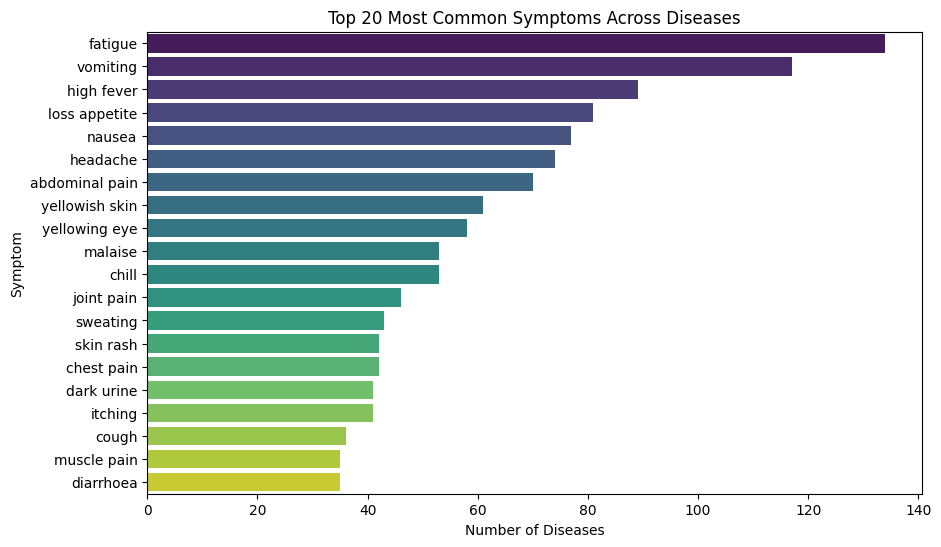

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
# Count how many diseases each symptom is linked to
symptom_counts = {}
for _, row in disease_symptom_df.iterrows():
    for col in symptom_cols:
        symptom = row[col]
        if symptom != "unknown":
            symptom_counts[symptom] = symptom_counts.get(symptom, 0) + 1

symptom_freq_df = pd.DataFrame.from_dict(symptom_counts, orient="index", columns=["disease_count"]).reset_index()
symptom_freq_df.rename(columns={"index": "Symptom"}, inplace=True)
# Top 20 most common symptoms across diseases
# -----------------------------------------------------
top_symptoms = symptom_freq_df.sort_values(by="disease_count", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top_symptoms, x="disease_count", y="Symptom", palette="viridis")
plt.title("Top 20 Most Common Symptoms Across Diseases")
plt.xlabel("Number of Diseases")
plt.ylabel("Symptom")
plt.show()

**During agentic flow testing, discovered multiple cases and addressed each individually.**

In [31]:
print("Descriptions duplicates:", disease_description_df["Disease"].duplicated().sum())
dupe_names = disease_description_df[disease_description_df["Disease"].duplicated(keep=False)]["Disease"].unique()
print("Duplicated disease(s):", dupe_names)
disease_description_df = (
    disease_description_df
    .groupby('Disease')['Description']
    .apply(lambda x: " | ".join(set(x)))
    .reset_index()
)
print("Descriptions duplicates:", disease_description_df["Disease"].duplicated().sum())
dupe_names = disease_description_df[disease_description_df["Disease"].duplicated(keep=False)]["Disease"].unique()
print("Duplicated disease(s):", dupe_names)

Descriptions duplicates: 1
Duplicated disease(s): ['hepatitis']
Descriptions duplicates: 0
Duplicated disease(s): []


In [32]:
non_numeric = disease_symptom_long[pd.to_numeric(disease_symptom_long['weight'], errors='coerce').isna()]
if not non_numeric.empty:
    print("Warning: some weights were non-numeric and set to 0.0")
    print(non_numeric)

In [33]:
# This code identifies non-numeric or missing 'weight' values and sets them to 0.0.

# Convert to numeric, coercing errors → NaN
symptom_severity_df['weight'] = pd.to_numeric(symptom_severity_df['weight'], errors='coerce')
# Replace NaN with 0.0
symptom_severity_df['weight'] = symptom_severity_df['weight'].fillna(0.0)

# Report non-numeric (now NaN) values
non_numeric = symptom_severity_df[symptom_severity_df['weight'].isna()]

if not non_numeric.empty:
    print("⚠️ Warning: some weights were invalid or missing and will be set to 0.0")
    print(non_numeric)


Alignment rules are taken care now.
* Symptoms: disease_symptom_df → symptom_severity_df
* Every symptom in disease_symptom_df exists in symptom_severity_df.
* Merged to get weight.
* Diseases: disease_symptom_df → disease_description_df & disease_precaution_df
* Every disease in disease_symptom_df have corresponding description and set of precautions.

##**MediBot Implementation**

**MediBot** is an **NLP-based, multi-turn conversational** medical assistant that provides **context-aware, personalized guidance**. Built with a **React**-style interface using **LangChain agents**, it combines **RAG with a FAISS engine** for efficient knowledge retrieval. The system is **multi-modal**, handling both **text and image** inputs, and maintains a **user-specific conversation history** to deliver an interactive and educational experience.

**Features**

**Multi-Turn ReAct Workflow**:
Supports multi-turn conversations using reasoning → acting → context-aware feedback loops.

**Context-Aware LLM Router:**
Routes queries dynamically to appropriate agents (disease diagnosis, symptom severity, description, precautions) based on user input and conversation context.

**LLM Fallback:**
Handles unknown, ambiguous, or non-health queries safely with user-friendly educational responses.

**FAISS Vector Store Retrieval:**
Retrieves relevant disease–symptom mappings for accurate diagnosis and recommendations.

**Persistent & Session Memory:**

Persistent memory stores historical context across sessions.

Session memory maintains short-term conversational context for multi-turn queries.

**Free-Flow Summary**:
Generates a user-friendly, contextual summary based on prior queries and agent outputs.

**Clarification Handling:**
Detects ambiguous or unclear user input and asks for clarification dynamically.

**Structured Output:**
Returns disease-specific severity, description, and precautions in a clear, structured format.

**Interactive Gradio Interface:**
Provides a user-friendly, web-based interface for text and image inputs, real-time chatbot responses, feedback collection, and visualization of conversation history, summaries, and memory.



## **System Architecture Diagram**

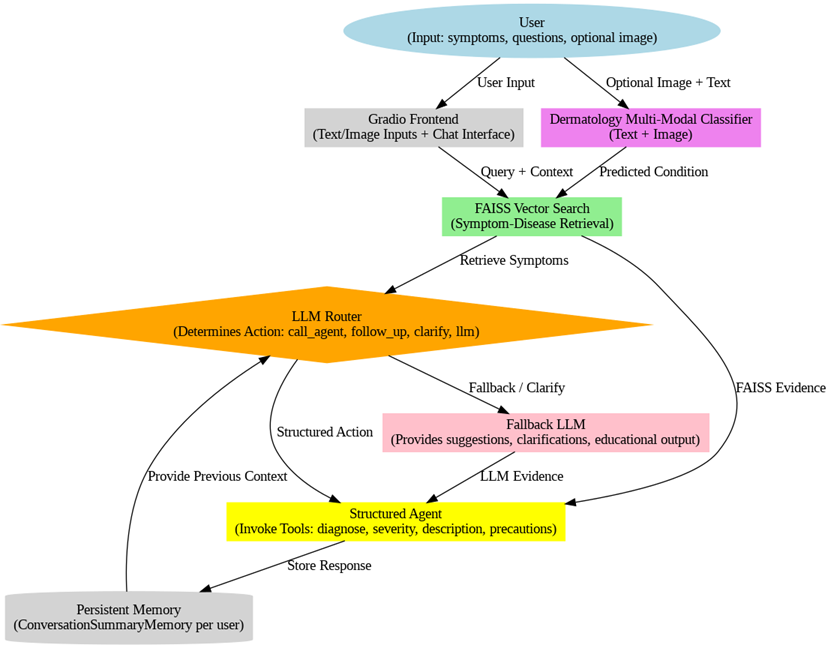

In [34]:
#Helper function
import json, datetime

import datetime
import json
import os

def trace_event(
    step: str,
    details: dict = None,
    verbose: bool = False,
    show_time: bool = False,
    capture_log: list = None,
    log_file: str = "trace_log.txt"  # New argument for disk logging
):
    """
    Generic tracer for debugging, live streaming, and disk logging.
    Prints to console, appends to a log list, and saves to disk.

    Args:
        step (str): Step name, e.g., "FAISS Retrieval"
        details (dict, optional): Data to log
        verbose (bool, optional): If True, print to console
        show_time (bool, optional): Include timestamp
        capture_log (list, optional): Append message for live streaming
        log_file (str, optional): File path to save logs on disk
    """
    ts = f"[{datetime.datetime.now().isoformat()}] " if show_time else ""
    header = f"{ts}=== {step} ==="

    # Compose message
    message = header
    if details:
        try:
            message += "\n" + json.dumps(details, indent=2, ensure_ascii=False)
        except Exception:
            message += "\n" + str(details)

    # Print to console
    if verbose:
        print(message)

    # Append to capture log
    if capture_log is not None:
        capture_log.append(message)

    # Save to disk (append mode)
    try:
        with open(log_file, "a", encoding="utf-8") as f:
            f.write(message + "\n\n")
    except Exception as e:
        if verbose:
            print(f"[trace_event] Failed to write log to {log_file}: {e}")


In [35]:
#Helper function
# Safe single-call wrapper
import traceback
def safe_agent_call(agent_executor, llm, agent_prompt, show_react_trace=False):
    """
    Attempt agent_executor.run(...) first (preserve show_react_trace prints),
    then fallback to llm.invoke(...). Returns raw agent_text (string).
    """

    # Log the agent prompt for debugging
    trace_event("Agent Prompt", {"agent_prompt": agent_prompt}, show_react_trace)

    agent_resp = ""

    # Try executing the agent first
    try:
        if agent_executor:
            agent_resp = agent_executor.invoke({"input":agent_prompt})
            # Trace agent executor response
            trace_event("response(agent_resp)", {"resp": agent_resp}, show_react_trace)
    except Exception:
        # Log traceback if agent execution fails
        trace_event("traceback.print_exc()", {traceback.print_exc()},show_react_trace)
        agent_resp = ""

    # Fallback to LLM if agent returned nothing
    if (not agent_resp) and llm:
        try:
            resp = llm.invoke(agent_prompt)
            # Trace LLM response
            trace_event("LLM response", {"resp": resp}, show_react_trace)
            agent_resp = getattr(resp, "content", str(resp))
        except Exception:
            agent_resp = ""

    # Final fallback if both agent and LLM fail
    if not agent_resp:
        agent_resp = f"## \nNo data available."

    # Return the agent/LLM response
    return agent_resp


In [36]:
#Helper function
import textwrap

def format_freeflow_output(llm_output: str, user_query: str, width: int = 90) -> str:
    """
    Format free-flow LLM output into user-facing Markdown with proper text wrapping.

    Args:
        llm_output (str): The LLM's free-flow text output.
        user_query (str): The user's query for context.
        width (int): The maximum line width before wrapping (default 90 chars).

    Returns:
        str: Markdown-formatted text suitable for Gradio or Colab display.
    """
    # Add user query header
    header = f"### 👨 Your Concern- {textwrap.fill(user_query, width=width)}\n\n"

    # Remove "Final Answer:" prefix
    clean_text = re.sub(r"^\s*Final_Answer:\s*", "", llm_output.strip(), flags=re.IGNORECASE)

    # Ensure clean spacing between paragraphs
    paragraphs = [p.strip() for p in clean_text.split("\n") if p.strip()]

    # Wrap each paragraph cleanly
    wrapped_paragraphs = [textwrap.fill(p, width=width) for p in paragraphs]

    # Combine with emojis and Markdown line breaks
    formatted_output = "🤖  " + "\n\n".join(wrapped_paragraphs)

    return header + formatted_output


In [37]:
#Helper function
def generate_user_friendly_markdown(final_answer_dict: dict, user_query: str) -> str:
    """
    Generate user-facing Markdown from structured JSON output.
    Expects final_answer_dict to have keys: Disease, Severity, Description, Precautions.

    Args:
        final_answer_dict (dict): Structured JSON output from LLM.
        user_query (str): Original user query.

    Returns:
        str: Markdown-formatted message.
    """

    # Start Markdown with user query
    markdown_message = f"### 👨 Your Concern-{user_query}\n\n"

    # 💊 Possible Diseases
    markdown_message += "### 💊 Possible Diseases\n"
    for i, d in enumerate(final_answer_dict.get("Disease", []), start=1):
        markdown_message += f"{i}. **{d['disease'].title()}**\n"

    # ⚠️ Severity
    severity_text = final_answer_dict.get("Severity", {}).get("severity", "Unknown")
    markdown_message += f"\n### ⚠️ Severity Assessment\n- Overall Severity: {severity_text}\n"

    # 📖 Descriptions
    markdown_message += "\n### 📖 Disease Descriptions\n"
    descriptions = {d['disease']: d['description'] for d in final_answer_dict.get("Description", [])}
    for d in final_answer_dict.get("Disease", []):
        desc = descriptions.get(d['disease'], "No description available.")
        markdown_message += f"- **{d['disease'].title()}**: {desc}\n"

    # 🛡️ Precautions
    markdown_message += "\n### 🛡️ Recommended Precautions\n"
    precautions_dict = {p['disease']: p['precautions'] for p in final_answer_dict.get("Precautions", [])}
    for d in final_answer_dict.get("Disease", []):
        prec_list = precautions_dict.get(d['disease'], [])
        markdown_message += f"- **{d['disease'].title()}**:\n"
        for p in prec_list:
            markdown_message += f"  - {p}\n"

    return markdown_message

In [38]:
import os  # Importing the os module to interact with environment variables
import getpass  # Importing getpass to securely input sensitive information

#  Prompting the user to securely enter their OpenAI API key without displaying it on the screen
OPENAI_API_KEY = getpass.getpass("Enter your OpenAI API key: ")
# Setting the OpenAI API key as an environment variable.
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

# Streaming allows tokens to be processed in real-time, reducing response latency.
# Run the agent with KV Cache enabled "streaming=True", This ensures that past responses are stored and reused efficiently.
llm = ChatOpenAI(model_name="gpt-4",temperature=0,streaming=True,openai_api_key=OPENAI_API_KEY)

# from langchain_community.chat_models import ChatOllama
# llm = ChatOllama(model="llama3", temperature=0)   # or "mistral", "gemma"
# session_memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)


Enter your OpenAI API key: ··········


/tmp/ipython-input-1332393179.py:11: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name="gpt-4",temperature=0,streaming=True,openai_api_key=OPENAI_API_KEY)


In [39]:
#FAISS engine
class FAISSBackend:
    def __init__(self, disease_symptom_df, symptom_severity_df=None,
             disease_precaution_df=None, disease_description_df=None,
             llm_client: OpenAI = None):

      # Store a copy of the disease-symptom DataFrame
      self.df = disease_symptom_df.copy()

      # Initialize sentence transformer model for embedding symptoms
      self.model = SentenceTransformer("all-MiniLM-L6-v2")

      # Store the optional LLM client for fallback reasoning
      self.llm_client = llm_client

      # Extract symptom texts and compute their embeddings
      self.symptom_texts = self.df['Symptom'].tolist()
      self.symptom_embeddings = self.model.encode(self.symptom_texts, convert_to_numpy=True)
      # Normalize embeddings for cosine similarity
      self.symptom_embeddings /= np.linalg.norm(self.symptom_embeddings, axis=1, keepdims=True)

      # Build FAISS index for fast similarity search
      dim = self.symptom_embeddings.shape[1]
      self.index = faiss.IndexFlatIP(dim)  # Inner-product index (cosine similarity with normalized vectors)
      self.index.add(self.symptom_embeddings.astype('float32'))  # Add embeddings to the index

      # Initialize disease info DataFrame with unique diseases
      self.disease_info = pd.DataFrame({'Disease': self.df['Disease'].unique()}).set_index('Disease')

      # Join disease descriptions if provided
      if disease_description_df is not None:
          self.disease_info = self.disease_info.join(
              disease_description_df.set_index('Disease')['Description'], how='left'
          )
      # Fill missing descriptions with a default message
      self.disease_info['Description'] = self.disease_info['Description'].fillna(
          pd.Series(self.disease_info.index + " is a medical condition.", index=self.disease_info.index)
      )

      # Process disease precautions if provided
      # --- Step 1: Ensure df_melted exists and is cleaned ---
      # df_melted should be long-format, one row per disease-precaution pair, no duplicates
      # Columns: ['Disease', 'Disease_ID', 'Precaution']

      # Step 2: Aggregate precautions into lists per disease
      precautions_per_disease = (
          df_melted.groupby('Disease')['Precaution']
          .apply(list)  # Collect all precautions for each disease into a list
      )

      # Step 3: Merge aggregated precautions into disease_info
      self.disease_info = self.disease_info.join(
          precautions_per_disease.rename('Precautions'),
          on='Disease',
          how='left'
      )

      # Step 4: Fill missing precautions with default if needed
      # self.disease_info['Precautions'] = self.disease_info['Precautions'].apply(
          # lambda x: x if isinstance(x, list) and len(x) > 0 else ["Consult a doctor"]
      # )


    # =========================
    # Symptom retrieval
    # =========================
    def retrieve_symptoms(self, query, top_n=5, threshold=0.5,show_trace = False):
      """
      Retrieve top matching symptoms from FAISS index above a threshold.
      If no results found, fallback to LLM (if available).
      """

      # Encode the query into a normalized embedding vector
      query_emb = self.model.encode([query], convert_to_numpy=True)
      query_emb /= np.linalg.norm(query_emb, axis=1, keepdims=True)

      # Perform a FAISS search to find top_n most similar symptoms
      D, I = self.index.search(query_emb.astype('float32'), top_n)

      results = []
      # Iterate over scores and indices returned by FAISS
      for score, idx in zip(D[0], I[0]):
          if score < threshold:  # Skip results below the similarity threshold
              continue
          row = self.df.iloc[idx]  # Retrieve the corresponding row from the dataframe
          weight = float(row.get('weight', 1.0))  # Get weight from row, default 1.0
          results.append({
              'Symptom': row['Symptom'],  # Symptom text
              'Disease': row['Disease'],  # Associated disease
              'Score': float(score),      # Similarity score
              'Weight': weight            # Weight for scoring
          })

      # LLM Fallback: if FAISS returns no results and an LLM client is available
      if not results and self.llm_client:
          response = self.llm_client.chat.completions.create(
              model="gpt-4o-mini",
              messages=[
                  {"role": "system", "content": "You are a medical assistant. Suggest possible diseases given symptoms."},
                  {"role": "user", "content": f"A patient reports: {query}. What could be possible causes?"}
              ]
          )
          llm_answer = response.choices[0].message.content
          # Add LLM suggestion as a result with Score=0 and Weight=1
          results = [{"Symptom": query, "Disease": "LLM suggestion", "Score": 0.0, "Weight": 1.0, "LLM_Output": llm_answer}]
      trace_event("results...retrieve_symptoms", {"results": results},show_trace)
      # Return the list of matched symptoms and associated info
      return results

    # =========================
    # Disease info retrieval
    # =========================
    def get_disease_info(self, disease,show_trace = False):
      # Check if the disease exists in the disease_info DataFrame; return defaults if not
      if disease not in self.disease_info.index:
          return f"{disease} is a medical condition.", ["Consult a doctor"]

      # Retrieve the row corresponding to the disease
      row = self.disease_info.loc[disease]

      # Get the description from the row, or use a default message if missing
      desc = row["Description"] if "Description" in row else f"{disease} is a medical condition."

      # If the description is a Series or list, extract the first element
      if isinstance(desc, (pd.Series, list)):
          desc = desc.iloc[0] if hasattr(desc, "iloc") else desc[0]

      # Ensure the description is a clean string without newline characters
      desc = str(desc).strip().replace("\n", " ")

      # Get the list of precautions from the row, or default to ["Consult a doctor"]
      precautions = row["Precautions"] if "Precautions" in row else ["Consult a doctor"]

      # If precautions is a single string, wrap it in a list
      if isinstance(precautions, str):
          precautions = [precautions]

      # If precautions is a Series, list, or tuple, flatten nested lists and convert to strings
      elif isinstance(precautions, (pd.Series, list, tuple)):
          flat = []
          for p in precautions:
              if isinstance(p, list):
                  flat.extend(map(str, p))  # Flatten inner lists
              elif pd.notna(p):
                  flat.append(str(p))       # Convert non-null elements to strings
          precautions = flat or ["Consult a doctor"]  # Ensure non-empty list

      # For any other unexpected type, fallback to a default precaution
      else:
          precautions = ["Consult a doctor"]

      # Return the description and list of precautions
      return desc, precautions


    # =========================
    # Disease description retrieval
    # =========================
    def get_disease_description(self, disease,show_trace = False):
        if disease not in self.disease_info.index:
            # return f"{disease} is a medical condition."
            return None

        row = self.disease_info.loc[disease]
        desc = row.get("Description", None)

        if isinstance(desc, (pd.Series, list)):
            desc = desc.iloc[0] if hasattr(desc, "iloc") else desc[0]
        trace_event("desc...get_disease_description", {"desc": desc},show_trace)
        return str(desc).strip().replace("\n", " ")
    # =========================
    # Disease precaution retrieval
    # =========================
    def get_disease_precautions(self, disease,show_trace = False):
      if disease not in self.disease_info.index:
          return ""

      row = self.disease_info.loc[disease]
      precautions = row.get("Precautions", "")

      # If it’s a string, wrap it
      if isinstance(precautions, str):
          precautions = [precautions]

      # If it’s a list-like, ensure all are strings
      elif isinstance(precautions, (list, pd.Series, tuple)):
          precautions = [str(p) for p in precautions if pd.notna(p)]
          if not precautions:
              precautions = ""

      else:
          precautions = ""

      # Remove duplicates while preserving order
      seen = set()
      precautions_unique = []
      for p in precautions:
          if p not in seen:
              seen.add(p)
              precautions_unique.append(p)
      trace_event("precautions_unique...get_disease_precautions", {"precautions_unique": precautions_unique},show_trace)
      return precautions_unique


faiss_backend = FAISSBackend(
  disease_symptom_df=disease_symptom_long,
  symptom_severity_df=symptom_severity_df,
  disease_precaution_df=disease_precaution_df,
  disease_description_df=disease_description_df
)

In [40]:
#Test FAISS
def testFAISresults(current_query: str):
  # Retrieve top diseases using FAISS
  faiss_results = faiss_backend.retrieve_symptoms(
      query=current_query,
      top_n=2,
      threshold=0.5
  )
  print(f"FAISS Retrieval: {faiss_results}")
  # Diagnose disease
  # faiss_results = {'Symptom': 'headache', 'Disease': 'paralysis brain hemorrhage', 'Score': 0.8207581043243408, 'Weight': 3.0}, {'Symptom': 'headache', 'Disease': 'hypertension', 'Score': 0.8207581043243408, 'Weight': 3.0}
  # current_query= ""
  current_query = "paralysis brain hemorrhage,hypertension"
  disease = diagnose_disease(query=current_query, faiss_evidence=faiss_results)
  print(f"Disease: {disease}")
  severity = assess_symptom_severity(query=current_query, faiss_evidence=faiss_results)
  print(f"Severity: {severity}")
  # faiss_results =""
  # current_query = "I have headache"
  current_query = "paralysis brain hemorrhage,hypertension"
  description = describe_disease(query=current_query, faiss_evidence=faiss_results)
  print(f"Description: {description}")
  # Pass to the tool / function
  precautions = advise_precautions(query=current_query, faiss_evidence=faiss_results)
  print(f"Precautions: {precautions}")
  return ""

  # current_query = "I have headache"
# current_query = "paralysis brain hemorrhage,hypertension"
# testFAISresults(current_query)


In [41]:
#Helper function
def llm_fallback_response(
    query: str,
    faiss_results=None,
    task: str = "diagnose disease",
    previous_queries=None,
    memory=None,
    **kwargs
):
    """
    Standardized LLM fallback for tools when FAISS retrieval fails.
    Returns Markdown string output.
    """
    if previous_queries is None:
        # Only fetch memory if caller didn't explicitly give previous_queries
        if memory is not None and hasattr(memory, "chat_memory"):
            # extract only the text content
            # memory.chat_memory.messages is a list of HumanMessage/AIMessage objects
            previous_queries = [m.content for m in memory.chat_memory.messages if hasattr(m, "content")]
        else:
            previous_queries = []

    prev_str = "\n".join(previous_queries) if previous_queries else "None"

    prompt = f"""
User asked: "{query}".
Previous queries (context only):
{prev_str}

Answer only the current query. Do not repeat previous diagnoses.
If the query is about seriousness, ER, or urgency, prioritize potential emergency conditions.
If available, consider these FAISS disease matches as context: {faiss_results or 'None'}.

Please {task} (educational purposes only). Return a structured Markdown response
with possible diseases, severity, descriptions, and precautions.
Always include a disclaimer that this is educational and not a substitute for professional care.
"""
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content if hasattr(response, "content") else str(response)

Multi-agent AI to assign specialized tasks:

    diagnose_disease Agent: Predicts probable illnesses.
    assess_symptom_severity Agent: Assesses the seriousness of symptoms.
    describe_disease Agent: Provides easy-to-understand explanations.
    advise_precautions Agent: Suggests preventive measures.

In [42]:
#Tools
# This function analyzes the input query to predict possible diseases based on FAISS retrieval results.
# It computes weighted confidence scores for each candidate disease and returns the top predictions.
# If no FAISS evidence is found, it falls back to an LLM-based suggestion.

def diagnose_disease(query: str,faiss_evidence = None,top_k=3,show_trace = False):
    """
    Returns a list of candidate diseases with confidence scores.
    Each item is a dictionary: {'disease': str, 'confidence': float}
    """
    results = faiss_evidence or []
    trace_event("FAISS Retrieval...diagnose_disease", {"query": query, "results": results},show_trace)
    if not results:
        # Return fallback as a dictionary for consistency
        note = llm_fallback_response(query, task="suggest possible diseases")
        trace_event("note from Normal Fallback...diagnose_disease", {"note": note},show_trace)
        return [{"disease": "Unknown", "confidence": 0.0, "note": note}]

    disease_scores = {}
    max_scores = {}
    for r in results:
        trace_event("r...diagnose_disease", {"r": r},show_trace)
        disease = r['Disease']
        symptom_weight = r.get('Weight', 1.0) * r.get('diagnostic_importance', 1.0)
        weighted_score = r['Score'] * symptom_weight
        disease_scores[disease] = disease_scores.get(disease, 0) + weighted_score
        max_scores[disease] = max_scores.get(disease, 0) + symptom_weight

    diseases_with_confidence = []
    for disease, score in disease_scores.items():
        max_score = max_scores.get(disease, 1.0)
        confidence = min(score / max_score, 1.0)
        confidence += np.random.uniform(0, 0.005)
        confidence = min(confidence, 1.0)
        diseases_with_confidence.append({"disease": disease, "confidence": confidence})

    sorted_diseases = sorted(diseases_with_confidence, key=lambda x: x["confidence"], reverse=True)[:top_k]
    trace_event("sorted_diseases...diagnose_disease", {"sorted_diseases": sorted_diseases},show_trace)
    return sorted_diseases


In [43]:
#Tool
# This function estimates the severity level of a symptom using FAISS retrieval data.
# It calculates a weighted severity score to classify the symptom as Low, Moderate, or High.
# If no evidence is found, it falls back to an LLM-based severity assessment.

def assess_symptom_severity(query: str,faiss_evidence = None, top_k=3,show_trace = False):
    """
    Returns structured severity info per query.
    Output: {'severity': 'Low'|'Moderate'|'High', 'score': float}
    """
    results = faiss_evidence or []
    trace_event("FAISS Retrieval...assess_symptom_severity", {"query": query, "results": results},show_trace)
    if results:
        # Compute weighted severity score
        severity_score = sum(r['Score'] * r['Weight'] for r in results)

        # Map score to severity level
        if severity_score >= 2.5:
            level = "High"
        elif severity_score >= 1.5:
            level = "Moderate"
        else:
            level = "Low"

        output = {"severity": level, "score": severity_score}

        # Log structured output to vector memory
        # vector_memory.add(query, {"tool": "symptom_severity", "output": output})
        trace_event("output...assess_symptom_severity", {"output": output},show_trace)
        return output

    # LLM fallback if no evidence
    llm_output = llm_fallback_response(query, task="assess severity level (Low/Moderate/High)")
    trace_event("llm_output...assess_symptom_severity", {"llm_output": llm_output},show_trace)
    output = {"severity": llm_output, "score": 0.0}

    return output


In [44]:
#tool
# This function retrieves structured disease descriptions using FAISS or LLM fallback.
# Workflow:
# 1. Use FAISS evidence if available.
# 2. If FAISS is missing, split the query by commas and attempt FAISS lookup for each term.
# 3. If FAISS lookup fails, use an LLM fallback for concise factual descriptions.
# Output: a list of dictionaries [{'disease': str, 'description': str}],
# with descriptions cleaned and truncated to 4 sentences.

def describe_disease(query: str, faiss_evidence=None,show_trace = False):
    """
    Returns structured disease descriptions.

    - If FAISS results exist → use them.
    - If FAISS is missing → split comma-separated query and try FAISS lookup for each.
    - If FAISS lookup fails → use LLM fallback.

    Output: list[dict] = [{'disease': str, 'description': str}]
    """
    descriptions = []
    seen = set()

    trace_event("FAISS Retrieval...describe_disease", {"query": query, "results": faiss_evidence},show_trace)
    trace_event("query...describe_disease", {"query": query},show_trace)
    # Normalize FAISS results into a list of diseases
    if faiss_evidence:
        diseases = [r.get("Disease") or r.get("disease") for r in faiss_evidence if (r.get("Disease") or r.get("disease"))]
    else:
        # Fallback to comma-separated query terms
        diseases = [d.strip() for d in query.split(",") if d.strip()]

    trace_event("diseases...describe_disease",  {"diseases": ", ".join(diseases) if diseases else "None found"},show_trace)

    if not diseases:
        # Normal Fallback
        note = "No disease found. Please provide the Symptoms of your concern."
        trace_event("note from Normal Fallback...describe_disease", {"note": note},show_trace)
        return [{"description": note}]

    # Loop through all diseases/symptoms (from FAISS or query)
    for disease in diseases:
        if disease in seen:
            continue
        seen.add(disease)


        # Try getting description from FAISS backend
        desc = None
        # if "faiss_backend" in globals():
        try:
            desc = faiss_backend.get_disease_description(disease)
        except Exception:
            desc = None
        trace_event("desc faiss_backend...describe_disease", {"desc": desc},show_trace)

        # Fallback to LLM if FAISS doesn't have it
        if not desc:
            desc = llm_fallback_response(
                    disease,
                    task="provide only a concise factual description of the disease, excluding severity, symptoms, causes, treatments, or related conditions"
                    )
            trace_event("desc from llm_fallback...describe_disease", {"disease": desc},show_trace)

        # Clean and shorten description
        desc = str(desc or "").replace("\n", " ").strip()
        parts = [p.strip().capitalize() for p in re.split(r'[.|;]', desc) if p.strip()]
        short_desc = " ".join(parts[:4]) if parts else "Description not available"

        descriptions.append({
            "disease": disease,
            "description": short_desc
        })
    trace_event("descriptions...describe_disease", {"descriptions": descriptions},show_trace)
    return descriptions


In [45]:
#tool
# This function retrieves structured disease precautions using FAISS evidence or an LLM fallback.
# Workflow:
# 1. Use FAISS evidence if available.
# 2. If FAISS is missing, split the query by commas and attempt FAISS lookup for each disease/symptom.
# 3. If FAISS lookup fails, use an LLM to generate the top recommended precautions.
# Output: a list of dictionaries [{'disease': str, 'precautions': list[str]}],
# with precautions cleaned, deduplicated, and defaulting to 'Consult a doctor' if none are found.

def advise_precautions(query: str, faiss_evidence=None,show_trace = False):
    """
    Returns structured disease precautions.

    - If FAISS results exist → use them.
    - If FAISS is missing → split comma-separated query and try FAISS lookup for each.
    - If FAISS lookup fails → use LLM fallback.

    Output: list[dict] = [{'disease': str, 'precautions': list[str]}]
    """
    precautions_list = []
    seen = set()
    trace_event("FAISS Retrieval...advise_precautions", {"query": query, "results": faiss_evidence},show_trace)
    trace_event("query...advise_precautions", {"query": query},show_trace)

    # Normalize FAISS results into a list of diseases
    if faiss_evidence:
        diseases = [r.get("Disease") or r.get("disease") for r in faiss_evidence if (r.get("Disease") or r.get("disease"))]
    else:
        # Fallback to comma-separated query terms
        diseases = [d.strip() for d in query.split(",") if d.strip()]

    trace_event("diseases...advise_precautions", {"diseases": diseases},show_trace)

    if not diseases:
        # Normal Fallback
        precautions_list.append({
            "disease": "No disease found.",
            "precautions": "Not able to provide precautions.Please consult your Doctor."
        })
        trace_event("precautions_list from Normal Fallback...advise_precautions", {"precautions_list": precautions_list},show_trace)
        return precautions_list

    # Loop through all diseases/symptoms (from FAISS or query)
    for disease in diseases:
        if disease in seen:
            continue
        seen.add(disease)

        # Try getting precautions from FAISS backend
        precautions = None

       # if "faiss_backend" in globals():
        trace_event("in for disease...advise_precautions", {"disease": disease},show_trace)
        try:
            precautions = faiss_backend.get_disease_precautions(disease)
        except Exception:
            precautions = None

        trace_event("precautions faiss_backend...advise_precautions", {"precautions": precautions},show_trace)

        # Fallback to LLM if FAISS doesn't have it
        if not precautions:
            note = llm_fallback_response(disease, task = (
                      "Provide only the top 4 recommended precautions for the disease. "
                      "Return them as a simple comma-separated list, without explanations, severity, symptoms, causes, or treatments. "
                      "Do not include any extra text or numbering, just the precautions."
                  ))
            # Ensure it's always a list
            precautions = note if isinstance(note, list) else [note]
            trace_event("precautions from llm_fallback...advise_precautions", {"precautions": precautions},show_trace)

        # Clean and deduplicate
        precautions = [str(p).strip() for p in precautions if p]
        precautions = list(dict.fromkeys(precautions)) or ["Consult a doctor"]

        precautions_list.append({
            "disease": disease,
            "precautions": precautions
        })
        trace_event("precautions_list...advise_precautions", {"precautions_list": precautions_list},show_trace)
    return precautions_list


In [46]:
#LLM Rounter
"""
LLM Router for MediBot

This function routes user queries to the appropriate action based on:
- FAISS disease retrieval results
- Previous AI responses (context)
- User query content

Actions include:
- "call_agent" for strong disease matches
- "follow_up" for contextual follow-up questions
- "clarify" for ambiguous or weak queries
- "llm" for safe, educational fallback responses

Ensures safe, context-aware, and JSON-formatted decisions.
"""

from typing import List
def llm_router_decision(
    user_query,
    llm,
    prev_ai_response = None,
    faiss_results = None,
    show_trace: bool = False,
):
    """
    Context-Aware LLM Router for MediBot

    This function determines the next action for the MediBot agent based on
    the user query, previous AI responses, and FAISS retrieval results.

    This router ensures MediBot behaves safely, context-aware, and provides
    educational fallback when uncertain.
    """
    # Extract top candidate diseases from FAISS results
    candidate_diseases = [r["Disease"] for r in faiss_results][:2]
    trace_event("Candidate Diseases", {"candidate_diseases": candidate_diseases}, show_trace)
    prev_ai_response = [
        msg.content
        for msg in session_memory.chat_memory.messages
        if msg.type == "ai"
    ]
    # Build the safe routing prompt for the LLM
    prompt = f"""
      You are MediBot, a medical assistant AI.

      User query: {user_query}
      FAISS candidate diseases: {candidate_diseases or 'None'}
      Previous context: {prev_ai_response or 'None'}
      Rules:
      1. If there are >=1 FAISS candidate diseases above threshold:
        - action = "call_agent"

       2. If Previous context exist and FAISS gives 0 and user query is a follow-up
        (e.g., "is it serious?", "what precautions?", "do I need to go to ER?", "Should I call Doctor?"):
        - action = "follow_up"

      3. If FAISS gives 0 or 1 weak match or query is ambiguous or gibberish:
        - action = "clarify"
        - Provide a educational user friendly follow-up question.

      4. If no match or query unrelated to health:
        - action = "llm"
        - Provide a safe, educational fallback answer.
      5. Action_input must always be non-empty. If unsure, use a generic prompt like "Could you clarify your question?"

      6. Always return valid JSON in a fenced block. Example:

      ~~~json
      {{
        "action": "clarify",
        "action_input": "Could you clarify your question?",
      }}
      ~~~
      """
    trace_event("Safe LLM Router Prompt", {"prompt": prompt}, show_trace)

    # Call the LLM with the constructed prompt
    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        content = getattr(response, "content", str(response))
        trace_event("LLM Response", {"content": content}, show_trace)
    except Exception as e:
        # Handle LLM call failures gracefully
        trace_event("LLM call failed", {"error": str(e)}, show_trace)
        content = f"LLM call failed: {str(e)}"

    trace_event("Safe LLM Router Raw Output", {"content": content}, show_trace)

    decision = None

    # Extract raw string from LLM response
    raw = content.get("content") if isinstance(content, dict) else str(content)

    # Try extracting JSON from fenced code block
    json_match = re.search(r"```json(.*?)```", raw, re.DOTALL)
    if not json_match:
        json_match = re.search(r"~~~json(.*?)~~~", raw, re.DOTALL)

    json_str = None
    if json_match:
        json_str = json_match.group(1).strip()
    else:
        # Fallback: maybe LLM returned plain JSON without fences
        json_str = raw.strip()

    # Try parsing JSON safely
    try:
        decision = json.loads(json_str)
    except json.JSONDecodeError:
        # Replace smart quotes if LLM used them
        cleaned = json_str.replace('“', '"').replace('”', '"').replace("’", "'")
        try:
            decision = json.loads(cleaned)
        except Exception:
            decision = None

    # Fallback decision if parsing fails
    if not decision:
        decision = {
            "action": "llm",
            "action_input": raw.strip(),
            "descriptions": {},
            "precautions": {},
            "severity": "Unknown"
        }

    # Normalize action field to lowercase
    decision["action"] = decision.get("action", "llm").strip().lower()

    # Return the final router decision dictionary
    return decision


In [47]:
# test - llm_router_decision
def test_llm_router_decision():
  candidate_diseases = [{'Symptom': 'headache', 'Disease': 'paralysis brain hemorrhage', 'Score': 0.8207579851150513, 'Weight': 3.0}, {'Symptom': 'headache', 'Disease': 'hypertension', 'Score': 0.8207579851150513, 'Weight': 3.0}]
  user_query = "I have a headache"

  decision = llm_router_decision(
      user_query = user_query,
      llm = llm,
      prev_ai_response = None,
      faiss_results = candidate_diseases,
      show_react_trace= False,
  )
  action = decision.get("action", "llm").lower()
  print(action)
  print(decision)

  candidate_diseases = []
  user_query = "is it serious"

  decision = llm_router_decision(
      user_query = user_query,
      llm = llm,
      prev_ai_response = None,
      faiss_results = candidate_diseases,
      show_react_trace= False,
  )

  action = decision.get("action", "llm").lower()
  print(action)
  print(decision)

  #test - llm_router_decision
  candidate_diseases = []
  user_query = "is it serious"
  merged_context = "" #prev_ai_messages_to_context(session_memory)
  print(merged_context)
  decision = llm_router_decision(
      user_query = user_query,
      llm = llm,
      prev_ai_response = merged_context,
      faiss_results = candidate_diseases,
      show_react_trace= False,
  )


  action = decision.get("action", "llm").lower()
  print(action)
  print(decision)

  #test - llm_router_decision
  candidate_diseases = []
  user_query = "can I call ER"

  decision = llm_router_decision(
      user_query = user_query,
      llm = llm,
      prev_ai_response = None,
      faiss_results = candidate_diseases,
      show_react_trace= False,
  )


  action = decision.get("action", "llm").lower()
  print(action)
  print(decision)

  #test - llm_router_decision
  candidate_diseases = []
  user_query = "sdfsd ssfsfs"

  decision = llm_router_decision(
      user_query = user_query,
      llm = llm,
      prev_ai_response = None,
      faiss_results = candidate_diseases,
      show_react_trace= False,
  )
  action = decision.get("action", "llm").lower()

  return ""

In [48]:
#Tool REgistration
from langchain.tools import StructuredTool
"""
MediBot Structured Tools Setup

This section defines the set of StructuredTools used by the MediBot agent
for medical diagnosis and guidance. Each tool is a function wrapped as a
StructuredTool, enabling the agent to call it programmatically.
"""

diagnose_tool = StructuredTool.from_function(
    func=diagnose_disease,
    name="diagnose_disease",
    description="Predicts probable diseases from symptoms."
)

severity_tool = StructuredTool.from_function(
    func=assess_symptom_severity,
    name="symptom_severity",
    description="Assesses severity of symptoms."
)

description_tool = StructuredTool.from_function(
    func=describe_disease,
    name="disease_description",
    description="Provides disease description using faiss_evidence."
)

precautions_tool = StructuredTool.from_function(
    func=advise_precautions,
    name="advise_precautions",
    description="Provides recommended precautions using faiss_evidence."
)

tools= [diagnose_tool, severity_tool, description_tool, precautions_tool]


In [49]:
import json
import os
from langchain.memory import ConversationBufferMemory
from langchain.schema import HumanMessage, AIMessage

class PersistentMemory:
    def __init__(self, base_dir="user_histories"):
        self.base_dir = base_dir
        os.makedirs(base_dir, exist_ok=True)
        self.user_memories = {}  # in-memory cache per user

    def _get_file_path(self, user_id):
        """Return the path to a user's JSON file"""
        safe_id = str(user_id).replace("/", "_").replace("\\", "_")
        return os.path.join(self.base_dir, f"{safe_id}.json")

    def _get_user_memory(self, user_id):
        """Load or return cached ConversationBufferMemory for a user, for full session log"""
        if user_id not in self.user_memories:
            mem = ConversationBufferMemory(return_messages=True)
            self.user_memories[user_id] = mem
            self.load_from_disk(user_id)
        return self.user_memories[user_id]

    def add_user_message(self, user_id, text):
        mem = self._get_user_memory(user_id)
        mem.chat_memory.add_message(HumanMessage(content=text))
        self.save_to_disk(user_id)

    def add_ai_message(self, user_id, text):
        mem = self._get_user_memory(user_id)
        mem.chat_memory.add_message(AIMessage(content=text))
        self.save_to_disk(user_id)

    def get_messages(self, user_id):
        mem = self._get_user_memory(user_id)
        return mem.chat_memory.messages

    def save_to_disk(self, user_id):
        """Write a user's chat history to disk as JSON"""
        mem = self._get_user_memory(user_id)
        data = [
            {"role": "user", "content": m.content}
            if isinstance(m, HumanMessage)
            else {"role": "assistant", "content": m.content}
            for m in mem.chat_memory.messages
        ]
        path = self._get_file_path(user_id)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

    def load_from_disk(self, user_id):
        """Read chat history for a user if it exists"""
        path = self._get_file_path(user_id)
        if not os.path.exists(path):
            return
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
            mem = self._get_user_memory(user_id)
            for msg in data:
                if msg["role"] == "user":
                    mem.chat_memory.add_message(HumanMessage(content=msg["content"]))
                else:
                    mem.chat_memory.add_message(AIMessage(content=msg["content"]))
        except Exception as e:
            print(f"⚠️ Failed to load {user_id}'s history: {e}")


In [50]:
from langchain.memory.summary import ConversationSummaryMemory
#MediBot Agent and Session Memory Setup

# Using ConversationSummaryMemory to keep check on token limits are a concern
# Also Stores a summary of past conversations instead of full text and Keeps token usage manageable by summarizing context.
# Initializes and caches per-user session memory; creates each ConversationSummaryMemory only once
def create_user_sessionmemory(user_id: str, llm,show_trace = False):
  global user_sessionmemory_store

  if user_id not in user_sessionmemory_store:
      user_sessionmemory_store[user_id] = ConversationSummaryMemory(
                memory_key=f"chat_history_{user_id}",
                llm=llm,
                return_messages=True,
                max_token_limit=7000
            )
      trace_event("create_user_sessionmemory", {"user_id": user_id},show_trace)
      trace_event("user_sessionmemory_store", {"user_sessionmemory_store": user_sessionmemory_store},show_trace)
  return user_sessionmemory_store[user_id]

agent_executor = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.OPENAI_FUNCTIONS, #structured, deterministic
    #memory=session_memory, # setting this, summary would be saved as human message, i just need query to be saved, to keep it simple. so not setting here.
    system_message="You are MediBot, a medical assistant AI.",
    verbose=True, # Logs step-by-step execution
    max_iterations=8,
    handle_parsing_errors=True) # Prevents agent from crashing due to unexpected outputs

/tmp/ipython-input-28863426.py:21: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  agent_executor = initialize_agent(


In [51]:
#Helper for new query prompt
def call_agents_for_new_query(query: str, faiss_results: List[dict],llm,show_react_trace = False):
    """
    Handle a new user query and FAISS evidence.
    Returns raw LLM output.
    """
    faiss_json = json.dumps(faiss_results)

    agent_prompt = f"""
You are MediBot, a medical assistant AI.

User Query: {query}
FAISS Evidence: {faiss_json}

Tools available:
1. diagnose_tool(query, faiss_evidence)
2. severity_tool(query, faiss_evidence)
3. description_tool(query, faiss_evidence)
4. precautions_tool(query, faiss_evidence)

Rules:
- You must call all tools until all four fields are filled: Disease, Severity, Description, Precautions.
- Call diagnose_disease tool as first tool, make sure you call all other tools after that.
- Provide User Query and FAISS Evidence in each tool call, it is a must.
- After calling a tool, include its Observation.
- After observing, decide the next tool to call.
- Do not skip any tool, even if you already have partial information.
- Only compile the Final Answer once all fields are collected.

ReAct Step Format:
Thought: <Your reasoning for which tool to call next>
Action: <tool name>
Action Input (JSON): {{ "query": "...", "faiss_evidence": [...] }}
Observation: <output from the tool>

After all steps, return Final Answer in this exact JSON format:
Final_Answer:
{{
  "Disease": [{{"disease": "...", "confidence": ...}}, ...],
  "Severity": {{"severity": "...", "score": ...}},
  "Description": [{{"disease": "...", "description": "..."}}, ...],
  "Precautions": [{{"disease": "...", "precautions": [...]}}, ...]
}}
"""

    # Call agent / LLM executor
    # llm_output = agent_executor.run(agent_prompt)
    llm_output = safe_agent_call(agent_executor, llm, agent_prompt, show_react_trace)
    trace_event("LLM output", {"llm_output": llm_output},show_react_trace)
    return (llm_output)


In [53]:
#helper for follow up query
def call_agents_for_followup_query(query: str, faiss_results: List[dict],llm,prev_ai_response,show_react_trace = False):
  """
  Handle a follow-up query and FAISS evidence.
  Returns raw LLM output.
  """

  faiss_json = json.dumps(faiss_results)

  agent_prompt = f"""
You are MediBot, a medical assistant AI.

User Query: {query}
FAISS Evidence: {faiss_json}

Tools available:
1. diagnose_tool(query, faiss_evidence)
2. severity_tool(query, faiss_evidence)
3. description_tool(query, faiss_evidence)
4. precautions_tool(query, faiss_evidence)

Previous Diagnosis Context: {prev_ai_response}

Rules:
  - Answer the user's query using the previous context.
  - Call appropriate tools if necessary.
  - If the user asks about severity, description, or precautions, use this context.
  - Generate a concise,educational and empathetical user-friendly answer, return Final_Answer.
"""
  # llm_output = agent_executor.run(agent_prompt)
  llm_output = safe_agent_call(agent_executor, llm, agent_prompt, show_react_trace)
  trace_event("LLM output", {"llm_output": llm_output},show_react_trace)
  return (llm_output)

## **MediBot Multi-Turn Flow**

At the start, I implemented an **LLM router** to determine **when to call agents** based on FAISS retrieval **(RAG)**. This approach helps **reduce LLM hallucination**s and generate more **deterministic responses**, while avoiding unnecessary agent calls that could **increase prompt length**, confuse agents, and potentially lead to hallucinations.

I set up **two distinct agent prompts**:

* **Full-agent prompt** – calls all relevant agents to gather comprehensive information for a structured, user-facing response.

* **Follow-up prompt** – handles clarifications or additional queries based on previous conversation context.

This separation ensures agents receive **clear instructions**, which improves the determinism of their responses.

  * Additionally, I used AgentType.OPENAI_FUNCTIONS instead of "CHAT_CONVERSATIONAL_REACT_DESCRIPTION" because the latter stores summaries of the full prompt, which can be unnecessary and may cause **loss of important information or hallucinations**.

This sets **ReAct-based reasoning** to let the AI autonomously select the right agent.

For **memory management,**

To manage token limits, I leveraged ConversationSummaryMemory, which stores a **summary of past conversations** rather than the full text, keeping token usage manageable while still preserving relevant context.

I implemented **personalized user histories** using ConversationSummaryMemory. Only the **user query** is stored as a human message, and the **agent’s final response** is stored as the AI message. Each user has a **unique memory instance**, keyed by user_id, which:
  * Keeps memory **concise and focused**, mitigating hallucinations.

  * Maintains **context consistency** across multi-turn interactions

  * Tracks **recurrent health issues** for better continuity and personalized follow-up advice.

  * Ensures multi-turn conversations are **user-specific**, even across multiple sessions if memory is persisted.

This combination of **RAG-based retrieval, ReAct based  multi-agent routing, and personalized memory** allows MediBot to provide **structured, context-aware, and deterministic** medical guidance tailored to each user


### MediBot flowchart

**Key Points / Notes**

**Context-Aware**  All responses consider previous AI messages via merged_context.

**Retrieval-First Approach** FAISS ensures high-confidence disease matches before agent or LLM execution.

**Router-Based Decision** LLM decides the next step dynamically: clarify, follow-up, free-flow, or call agent.

**Agent Workflow**
* Only invoked for actionable cases to produce structured diagnosis.
* Uses ReAct-style reasoning tools.

**LLM Fallback** Ensures users always get educational guidance if no matches found.

**Session Memory** Updated session memory with the user query and AI response. Not with whole prompt.

**User-Friendly Markdown Output** Structured sections for diseases, severity, descriptions, and precautions.

**Traceable / Debuggable** Optional trace_event() logging at each step for monitoring or debugging.



```
User Query
   │
   ▼
Merge Previous AI Messages → Create merged_context
   │
   ▼
FAISS Retrieval → Are there matching diseases?
   ├─ Yes
   │    ├─ Router Decision → Determine action:
   │    │    • clarify
   │    │    • llm (free-flow)
   │    │    • follow_up
   │    │    • call_agent
   │    │
   │    └─ Action Handling:
   │         ├─ clarify / llm
   │         │    └─ Generate free-flow educational response
   │         │         • Markdown output
   │         │
   │         ├─ follow_up
   │         │    └─ call_agents_for_followup_query()
   │         │     |    • Format free-flow markdown
   |         |     |
   |         |     | __LLM fallback if no reponse
   │         │
   │         └─ call_agent
   │              ├─ call_agents_for_new_query()
   │              │    | • ReAct agent tools:
   │              │    |    - diagnose_disease
   │              │    |     - symptom_severity
   │              │    |    - disease_description
   │              │    |     - advise_precautions
   |              |    |
   |              |    |___LLM fallback if no reponse
   |              |   
   |              |
   │              ├─ Extract final JSON answer from LLM output
   │              ├─ Update session memory with the user query and AI response
   │              └─ Generate user-friendly markdown:
   │                    🔍 Possible Diseases
   │                    ⚠️ Severity Assessment
   │                    📖 Disease Descriptions
   │                    🛡️ Recommended Precautions
   │
   └─ No
        │
        ▼
    LLM Fallback → Generate educational response:

```



###**Agents Interactions Flow**

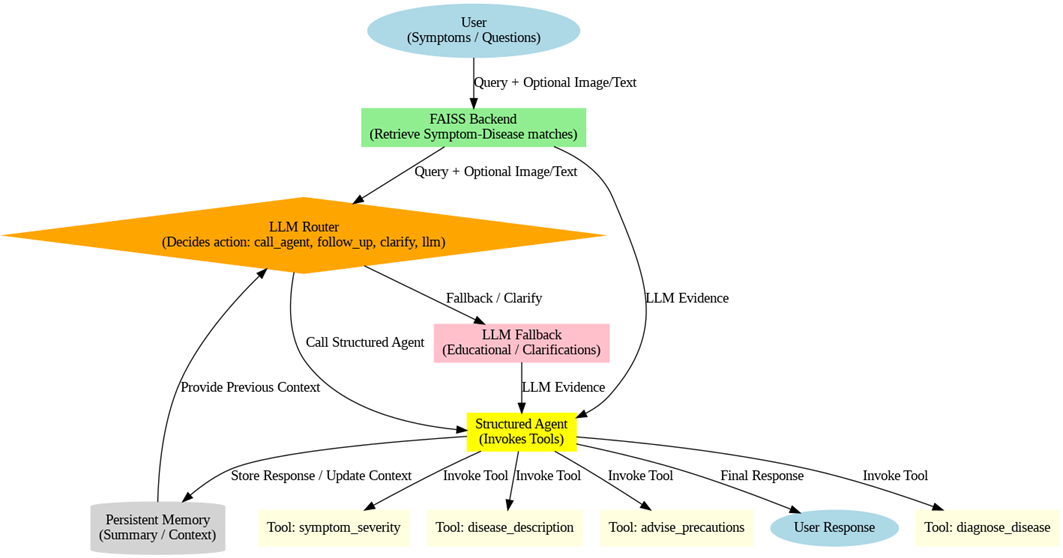

| Feature                       | Notes                                                                                                         |
| ----------------------------- | ------------------------------------------------------------------------------------------------------------- |
| Multi-turn context            | Uses `merged_context` to maintain continuity across queries                                                   |
| Retrieval-augmented reasoning | FAISS ensures high-confidence matches before calling the LLM                                                  |
| Router-based action selection | Dynamically selects the best next step: clarify, follow-up, free-flow, or agent call                          |
| Structured agent workflow     | Only calls ReAct agent tools when appropriate                                                                 |
| Robust fallback               | Always provides an educational response even when there are no retrieval hits                                 |
| Session memory                | Updated with the user query and AI response; does not store the entire prompt                                 |
| Markdown output               | User-friendly and visually structured for readability                                                         |
| Personalized user history     | Stores per-user memory of past queries and agent responses to improve contextual understanding and follow-ups |






In [54]:
def context_aware_mediBot_router(
    query: str,
    llm=None,
    faiss_backend=None,
    agent_executor=None,
    faiss_top_n: int = 2,
    faiss_threshold: float = 0.5,
    show_react_trace: bool = False,
):
    """
    Purpose: Handles multi-turn user symptom queries with context-awareness,
    retrieval, agent reasoning, and fallback logic.

    Goal: Provide structured, user-friendly responses including possible diseases,
    severity, descriptions, and precautions.

    Key Components:
    - FAISS Retrieval → high-confidence symptom-disease matches
    - Router LLM → decides next action
    - Agent Tools → execute diagnosis, severity scoring, and advice
    - LLM Fallback → structured educational output if no matches found
    """

    # Store the current user query
    current_query = query
    # Initialize a list to capture intermediate trace messages for debugging
    trace_messages = []

    # previous AI messages from session_memory to maintain context
    prev_ai_response = [
        msg.content
        for msg in session_memory.chat_memory.messages
        if msg.type == "ai"
    ]
    trace_event(
        "prev_ai_response",
        {"prev_ai_response": prev_ai_response},
        show_react_trace,
        capture_log=trace_messages
    )

    # --------------------------
    # Step 1: FAISS Retrieval
    # --------------------------
    # Retrieve relevant symptom-disease matches from FAISS
    # Only run if faiss_backend is provided; else return empty list

    faiss_results = faiss_backend.retrieve_symptoms(
        query=current_query,
        top_n=faiss_top_n,
        threshold=faiss_threshold
    ) if faiss_backend else []

    trace_event(
        "FAISS Retrieval",
        {"faiss_results": faiss_results},
        show_react_trace,
        capture_log=trace_messages
    )

    # --------------------------
    # Step 2: Router decision
    # --------------------------
    # Use the router LLM to decide the next action based on:
    # - current user query
    # - merged context from previous messages
    # - FAISS retrieval results
    decision = llm_router_decision(
        user_query=current_query,
        llm=llm,
        prev_ai_response=prev_ai_response,
        faiss_results=faiss_results,
        show_trace=show_react_trace
    )

    # Log the router decision for tracing/debugging
    trace_event("Router decision", {"decision": decision}, show_react_trace)
    # Default to 'llm' if action is not specified
    action = decision.get("action", "llm").lower()

    # --------------------------
    # Step 3: Final / free-flow answer
    # --------------------------
    if action in ["clarify", "llm"]:
        # Generate a free-flow or clarification response from the LLM
        llm_output = decision.get("action_input", "Could you clarify?")
        trace_event("LLM output", {"llm_output": llm_output}, show_react_trace)
        # Format LLM output into user-friendly markdown
        markdown_message = format_freeflow_output(llm_output, current_query)
        return markdown_message

    # --------------------------
    # Step 4: Follow-up agent query
    # --------------------------
    if action == "follow_up":
        # Call follow-up agent workflows for additional symptom clarification
        llm_output = call_agents_for_followup_query(
            current_query,
            faiss_results,
            llm,
            prev_ai_response,
            show_react_trace
        )

        agent_resp_text = llm_output["output"]

        # Capture everything after 'Final_Answer:'
        match = re.search(r'Final_Answer:\s*(.*)', agent_resp_text, re.DOTALL)

        if match:
            final_answer = match.group(1).strip()
            trace_event("final agent_resp", {"agent_resp": final_answer}, show_react_trace)
        else:
            final_answer = ""

        # Format output as markdown
        markdown_message = format_freeflow_output(agent_resp_text, current_query)
        return markdown_message

    # --------------------------
    # Step 5: Call structured agent
    # --------------------------
    if action == "call_agent":
        # Call agent tools for final diagnosis and structured response
        llm_output = call_agents_for_new_query(
            current_query,
            faiss_results,
            llm,
            show_react_trace
        )
        trace_event("LLM output(call_agent)", {"llm_output": llm_output}, show_react_trace)
        # Extract final JSON answer from LLM output
        agent_resp = llm_output["output"]
        match = re.search(r'Final_Answer:\s*(\{.*\})', agent_resp, re.DOTALL)

        if match:
            json_str = match.group(1)
            try:
                # Parse the JSON
                agent_resp = json.loads(json_str)
                trace_event("final agent_resp", {"agent_resp": agent_resp}, show_react_trace)
            except json.JSONDecodeError as e:
                trace_event("traceback.print_exc()", {traceback.print_exc()},show_react_trace)
                agent_resp = ""
        else:
            agent_resp = ""

        # Update session memory with the user query and AI response, not with whole prompt
        session_memory.chat_memory.add_user_message(current_query)
        session_memory.chat_memory.add_ai_message(json.dumps(agent_resp))

        # Generate user-friendly markdown response
        markdown_message = generate_user_friendly_markdown(agent_resp, current_query)
        return markdown_message


In [55]:
# -----------------------------
# Helper: Split multi-part user query
# -----------------------------
def split_user_query(query: str):
    """
    Split multi-part user query into smaller chunks (atomic symptom or question segments).
    Handles punctuation, conjunctions, and common meta-question cues.
    """
    q = query.replace("\n", " ").strip()
    segments = re.split(r'[,.!?]| and | but | now ', q, flags=re.IGNORECASE)
    segments = [s.strip() for s in segments if s.strip()]
    return segments

In [56]:
# -----------------------------
# Multi-segment MediBot handler
# -----------------------------
def handle_multi_segment_query(
    user_id: str,
    query: str,
    llm=None,
    faiss_backend=None,
    agent_executor=None,
    faiss_top_n: int = 2,
    faiss_threshold: float = 0.5,
    show_react_trace: bool = False
):
    """
    Handles multi-symptom/meta user queries with personalized memory.

    Steps:
    1. Splits user query into segments (e.g., by comma or 'and').
    2. Runs each symptom individually through MediBot pipeline.
    3. Combines Markdown-formatted outputs.

    Args:
        user_id (str): Unique identifier for the user.
        query (str): The full user query (possibly containing multiple symptoms).
        llm: LLM instance to use for reasoning.
        faiss_backend: Vector search backend.
        agent_executor: Agent runner (for ReAct-style reasoning).
        session_memory: Memory object for maintaining context.
        faiss_top_n (int): Number of FAISS matches per query.
        faiss_threshold (float): Similarity threshold.
        show_react_trace (bool): If True, display tool reasoning trace.

    Returns:
        str: Combined Markdown-formatted message summarizing all parts.
    """
    global persistent_memory
    # initialize or retrieve user memory
    if persistent_memory is None:
        persistent_memory = PersistentMemory()

    #Initialize session memory per user
    global session_memory
    session_memory = create_user_sessionmemory(user_id,llm,show_react_trace)

    trace_event("session_memory", {"session_memory": session_memory}, show_react_trace)
    # session_memory = user_sessionmemory_store[user_id]
    # Split user query into segments
    segments = split_user_query(query)
    combined_parts = []
    trace_event("segments", {"segments": segments}, show_react_trace)
    # Process each segment
    for segment in segments:
        segment = segment.strip()
        if not segment:
            continue

        # Call the context-aware agent router
        markdown_message = context_aware_mediBot_router(
            query=segment,
            llm=llm,
            faiss_backend=faiss_backend,
            agent_executor=agent_executor,
            faiss_top_n=faiss_top_n,
            faiss_threshold=faiss_threshold,
            show_react_trace=show_react_trace
        )
        trace_event("markdown_message", {"markdown_message": markdown_message}, show_react_trace)
        # Append the segment's output
        combined_parts.append(markdown_message.strip())

    # Combine all segment outputs
    combined_markdown = "\n\n---\n\n".join(combined_parts)

    # Save updated memory to disk
    persistent_memory.add_user_message(user_id, query)
    persistent_memory.add_ai_message(user_id, combined_markdown)
    trace_event("persistent_memory",{"persistent_memory",persistent_memory,show_react_trace})

    # initiating session memory summarization
    trace_event("session_memory", {"session_memory": session_memory}, show_react_trace)
    memory_data = session_memory.load_memory_variables({})
    memory_data = {"chat_history": []}
    trace_event("memory_data", {"memory_data": memory_data}, show_react_trace)

    if not memory_data.get("chat_history", []):
        #First time: no messages yet"
        # Add a human message
        session_memory.save_context(inputs={"input": query}, outputs={"output": ""})
        # Add AI response
        session_memory.save_context(inputs={"input": query}, outputs={"output": combined_markdown})

    return combined_markdown

##Gradio Interface

The MediBot interface provides an educational medical assistant with a structured layout. Users enter symptoms and a User ID, optionally upload images, and interact with a chatbot that displays conversation history. Action buttons allow clearing inputs, viewing summaries, and managing memory, while a dedicated feedback section collects ratings and comments, displaying messages above the input controls for clarity.

##Gradio interface Layout:

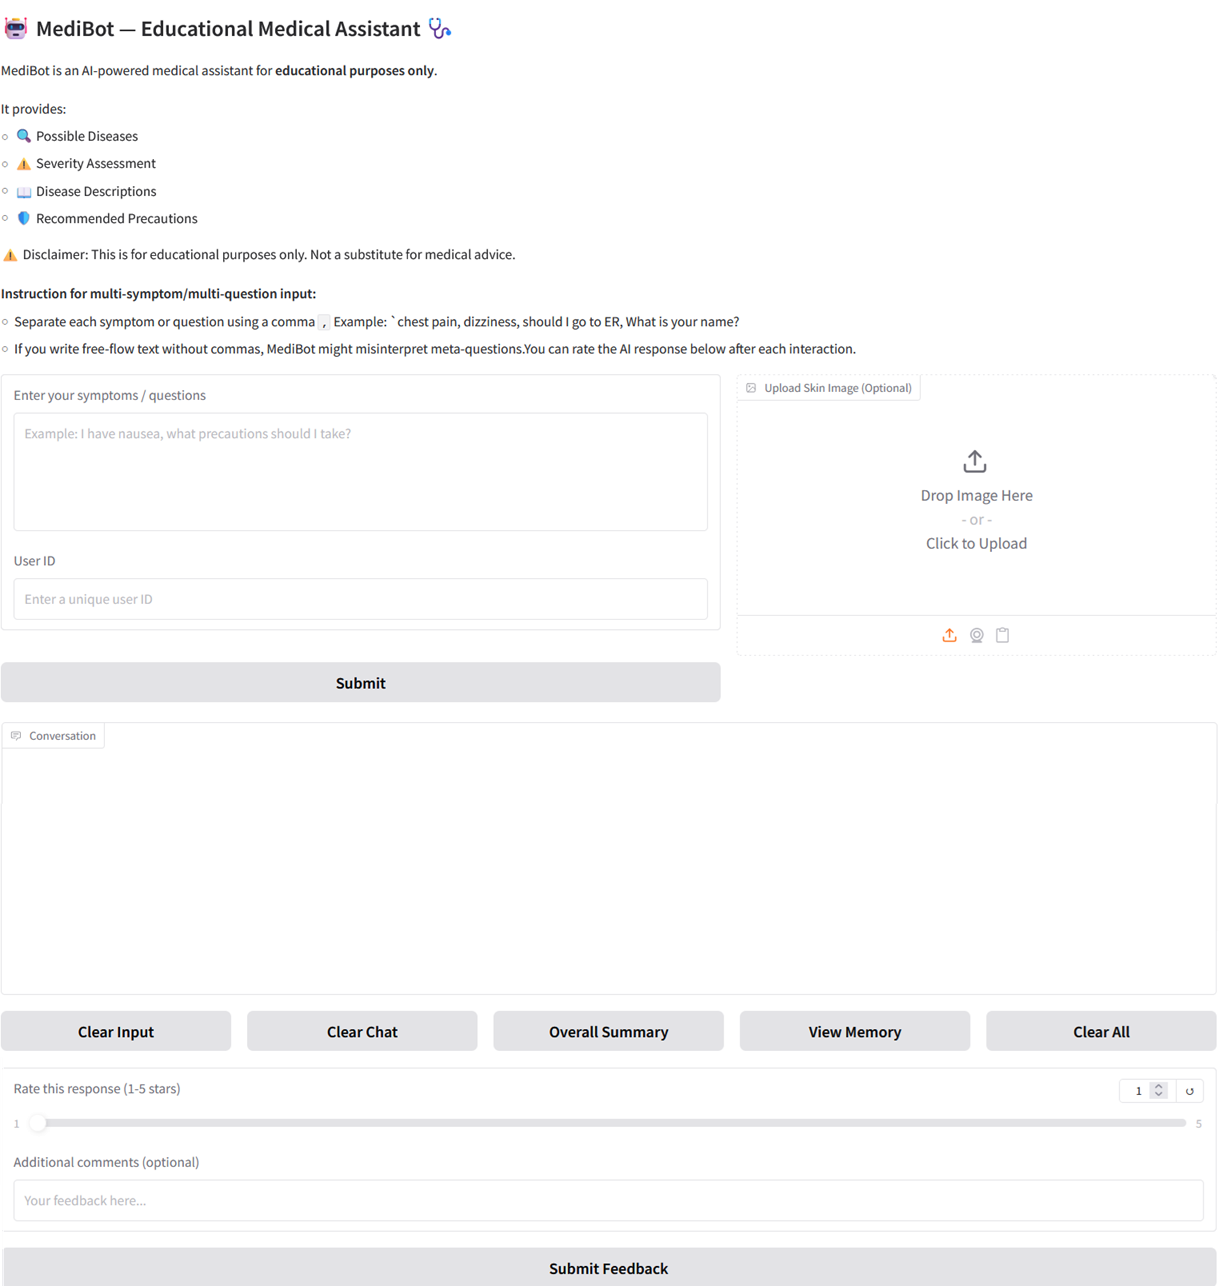

### 🩺 MediBot User Guide

This diagram represents the **MediBot interface** and workflow. Here's how each section works:

### 1. MediBot Markdown (Top Section)
- Displays **title, instructions, and disclaimers**.
- Read carefully before interacting.

### 2. User Input & Image Section (Columns)
- **Column 1:**
  - **User Input Textbox:** Type your query or symptoms. E.g I have a headache
  - **User ID Textbox:** Type user id like U12345 or user_12345.
  - **Validation Markdown:** Shows validation or errors.
  - **Submit Button:** Sends your input to MediBot.
- **Column 2:**
  - **User Image Upload:** Upload relevant images (e.g., skin lesions).

### 3. Chatbot Display
- Shows **conversation history** with MediBot.

### 4. Action Buttons
- **Clear Input:** Clears input textbox.
- **Clear Chat:** Clears conversation history.
- **Overall Summary:** Displays chat summary.session based.
- **View Memory:** Shows stored context.
- **Clear All:** Resets chat and memory.

### 5. Summary & Memory Output
- **Summary Output Markdown:** Conversation summary.
- **Memory Output Markdown:** Stored session memory.

### 6. Feedback Section
- **Feedback Message Markdown:** Shows feedback messages.
- **Rating Slider:** Rate your experience.
- **Additional Comments Textbox:** Optional text feedback.
- **Submit Feedback Button:** Sends feedback for processing.

### 7. Feedback Processing Workflow
- Function `collect_feedback(user_id, chat_history, rating, comment)` updates feedback.
- On submission:
  - Feedback messages displayed in **feedback_output Markdown**.
  - Comment textbox cleared.
  - Rating slider optionally reset.
  - Feddback is saved as .json at disk

---

**Tips for Users:**
- Read the top instructions before submitting queries.
- Use **Submit Button** after filling all required fields.
- Use the **feedback section** to help improve MediBot.
- Clearing chat or memory resets your session context.

In [57]:
# ===============================================
# Multi-Modal Dermatology Condition Classifier
# ===============================================
# Combines image features (ResNet50) + text features (SentenceTransformer)
# to predict dermatological conditions such as eczema, acne, psoriasis, etc.

import torch
from PIL import Image
from sentence_transformers import SentenceTransformer
from torchvision import models, transforms

# ----------------------------
# Text Encoder
# ----------------------------
print("Loading text model...")
text_model = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight and semantically strong

def encode_text(text: str) -> torch.Tensor:
    """Encode user text (symptom description) into an embedding tensor."""
    emb = text_model.encode(text, convert_to_tensor=True)
    return emb  # shape: [384]

# ----------------------------
# Image Encoder
# ----------------------------
print("Loading image encoder...")
resnet = models.resnet50(pretrained=True)
resnet.eval()
image_encoder = torch.nn.Sequential(*(list(resnet.children())[:-1]))  # remove last classifier layer

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def encode_image(image_path: str) -> torch.Tensor:
    """Convert image into ResNet feature embedding."""
    img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0)
    with torch.no_grad():
        features = image_encoder(img_tensor)  # shape: [1, 2048, 1, 1]
    return features.squeeze().flatten()  # [2048]

# ----------------------------
# Multi-Modal Fusion
# ----------------------------
def fuse_embeddings(text_emb: torch.Tensor, image_emb: torch.Tensor) -> torch.Tensor:
    """
    Fuse text + image embeddings into one representation.
    (Right now: simple concatenation. Later: can replace with cross-attention.)
    """
    return torch.cat([text_emb, image_emb], dim=0)

# ----------------------------
# Disease Classifier ---Sample
# ----------------------------
labels = [
    "eczema",
    "psoriasis",
    "acne",
    "fungal_infection",
    "allergy"
]
num_classes = len(labels)

fusion_dim = 384 + 2048  # text + image embedding dims

classifier = torch.nn.Sequential(
    torch.nn.Linear(fusion_dim, 512),
    torch.nn.ReLU(),
    torch.nn.Linear(512, num_classes)
)

# ----------------------------
# Inference Example
# ----------------------------
def predict_condition(user_text: str, image_path: str):
    """
    Given a symptom description and an image,
    predict the most likely skin condition.
    """
    text_emb = encode_text(user_text)
    image_emb = encode_image(image_path)
    fused = fuse_embeddings(text_emb, image_emb)

    logits = classifier(fused.unsqueeze(0))
    probs = torch.nn.functional.softmax(logits, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_idx].item()

    return {
        "predicted_condition": labels[pred_idx],
        "confidence": round(confidence, 3),
        "all_probs": {labels[i]: round(p, 3) for i, p in enumerate(probs.squeeze().tolist())}
    }

# ----------------------------
# Example Run
# ----------------------------
# user_text = "Red itchy rash on my forearm for 3 days"
# image_path = "rash_image.jpg"  # replace with a real image path

# result = predict_condition(user_text, image_path)

# print("\nDiagnosis Result")
# print(f"Predicted Condition : {result['predicted_condition']}")
# print(f"Confidence           : {result['confidence']}")
# print("All class probabilities:", result["all_probs"])



Loading text model...
Loading image encoder...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


In [58]:
#Gradio Helper
import json
from textwrap import indent

def submit_message_checked(user_input, chat_history, user_id, image=None):
    # Initialize chat_history if None
    if chat_history is None:
        chat_history = []

    # --------------------------
    # Validation
    # --------------------------
    if not user_id or user_id.strip() == "":
        # Keep both fields as-is, show validation
        return user_input, chat_history, '<span style="color:red">⚠️ Please enter your User ID</span>'

    if not user_input or user_input.strip() == "":
        # Keep user_id intact, show validation
        return user_input, chat_history, '<span style="color:red">⚠️ Please enter your symptoms or question</span>'

    # Clear validation if input is valid
    validation_msg = ""

    # --------------------------
    # Handle optional image
    # --------------------------
    if image is not None:
        try:
            result = predict_condition(user_input, image)  # Your image prediction function
            user_input = result.get('predicted_condition', user_input)
        except Exception as e:
            user_input += f"\n(Note: Image processing failed — {e})"

    # --------------------------
    # Append user message
    # --------------------------
    chat_history.append({"role": "user", "content": user_input})

    # --------------------------
    # Call bot / multimodal agent
    # --------------------------
    try:
        # response = "this is a test"
        response = handle_multi_segment_query(
                    user_id = user_id,
                    query = user_input,
                    llm=llm,
                    faiss_backend=faiss_backend,
                    agent_executor=agent_executor,
                    faiss_top_n = 2,
                    faiss_threshold = 0.5,
                    show_react_trace = False
                )
    except Exception as e:
        response = f'<span style="color:red">⚠️ MediBot encountered an error: {e}</span>'

    # Append bot response
    chat_history.append({"role": "assistant", "content": response})
    # --------------------------
    # Return
    # --------------------------
    # Clear only the user_input after successful submission; keep user_id intact
    return "", chat_history, validation_msg

# ----------------------------------------
# Feedback collection
# ----------------------------------------
# File path to store feedback
FEEDBACK_FILE = "feedback_store.json"

# Load existing feedback if file exists
if os.path.exists(FEEDBACK_FILE):
    with open(FEEDBACK_FILE, "r", encoding="utf-8") as f:
        feedback_store = json.load(f)
else:
    feedback_store = []

def save_feedback_to_disk():
    """Save current feedback_store to a JSON file."""
    with open(FEEDBACK_FILE, "w", encoding="utf-8") as f:
        json.dump(feedback_store, f, indent=2, ensure_ascii=False)

def collect_feedback(user_id, chat_history, rating, comment):
    """Collect feedback from user about the last response and save to disk."""

    if not chat_history:
        return '<span style="color:red">⚠️ No conversation yet to provide feedback.</span>', "",1

    feedback_item = {
        "user_id": user_id,
        "response_index": len(chat_history) - 1,
        "rating": rating,
        "comment": comment
    }
    feedback_store.append(feedback_item)

    # Save to disk after each submission
    save_feedback_to_disk()

    feedback_msg = f'<span style="color:green">Feedback submitted. Thank you, {user_id}!</span>'
    return feedback_msg, "",1
# ----------------------------------------
#  Clear All
# ----------------------------------------
def clear_all():
    # Order of return values must match outputs in clear_all_btn.click
    return (
        "",   # user_input
        [],   # chat_history_display
        "",   # summary_output
        "",   # memory_output
        "",   # feedback_output
        "",   # user_id_input
        "",   # validation_output
        "",   # feedback_comment
        1     # feedback_rating (reset to default 1)
    )

# ----------------------------------------
#  Over All Summary - session based
# ----------------------------------------

def get_overall_summary_sessionbased():
    try:
        # Ensure global variable is used
        global session_memory
        memory = session_memory

        if not memory:
            return "⚠️ No session memory for this user yet."

        # Try to load memory data
        memory_data = memory.load_memory_variables({})

        if not memory_data:
            return '<span style="color:red">⚠️ Memory data is empty.</span>'

        memory_key = list(memory_data.keys())[0]
        messages = memory_data.get(memory_key, [])

        # Look for the SystemMessage summary
        for msg in messages:
            if getattr(msg, "type", None) == "system":
                return msg.content

        return '<span style="color:red">⚠️ No summary available yet. Add some messages first.</span>'

    except AttributeError as e:
        # Likely caused by session_memory being the wrong type or uninitialized
        return f"<span style='color:red'>⚠️ Attribute error: {str(e)}</span>"

    except Exception as e:
        # Catch-all for unexpected errors
        return f"<span style='color:red'>⚠️ Unexpected error: {str(e)}</span>"


# ----------------------------------------
#  View Memory
# ----------------------------------------
def full_conversation(user_id):
    """
    Returns the complete conversation for a user as a readable string or HTML.
    """
    try:
        # Ensure persistent_memory is accessible
        global persistent_memory

        # Try to get messages for the user
        messages = persistent_memory.get_messages(user_id)

        if not messages:
            return '<span style="color:red">⚠️ No conversation found for this user.</span>'

        # Build the readable conversation
        output = "### 🗂️ Full Conversation History\n\n"
        for msg in messages:
            try:
                role = "User" if isinstance(msg, HumanMessage) else "Assistant"
                content = getattr(msg, "content", "")
                output += f"**{role}:** {content}\n\n"
            except Exception as e_inner:
                # Handle message-level issues gracefully
                output += f"<span style='color:red'>⚠️ Error reading message: {str(e_inner)}</span>\n\n"

        return output

    except AttributeError as e:
        # Common case: persistent_memory or get_messages is missing
        return f"<span style='color:red'>⚠️ Attribute error: {str(e)}</span>"

    except KeyError:
        return f"<span style='color:red'>⚠️ No data found for user ID {user_id}.</span>"

    except Exception as e:
        # Catch-all fallback
        return f"<span style='color:red'>⚠️ Unexpected error: {str(e)}</span>"



In [ ]:
import gradio as gr
from PIL import Image

# Placeholders to avoid NameError
feedback_output = None
feedback_comment = None
feedback_rating = None
feedback_btn = None

# ----------------------------------------
# Gradio Interface
# ----------------------------------------
with gr.Blocks(css="""
#feedback_text {font-size: 14px; color: #2b9348;}
#memory_output {font-size: 15px; background-color: #f9f9f9; padding: 10px; border-radius: 8px;}
""") as demo:

    gr.Markdown(
       "## 🤖 MediBot — Educational Medical Assistant 🩺\n"
        "MediBot is an AI-powered medical assistant for **educational purposes only**.\n\n"
        "It provides:\n"
        "- 🔍 Possible Diseases\n"
        "- ⚠️ Severity Assessment\n"
        "- 📖 Disease Descriptions\n"
        "- 🛡️ Recommended Precautions\n\n"
        "⚠️ Disclaimer: This is for educational purposes only. Not a substitute for medical advice.\n\n"
        "**Instruction for multi-symptom/multi-question input:**\n"
        "- Separate each symptom or question using a comma `,` Example: `I have chestpain, and feeling dizziness, should I go to ER, What is your name?`\n"
        "- If you write free-flow text without commas, MediBot might misinterpret meta-questions.\n"
        "You can rate the AI response below after each interaction."
    )

    # -------------------------------
    # User Input & Image
    # -------------------------------
    with gr.Row():
        with gr.Column(scale=3):
            user_input = gr.Textbox(
                label="Enter your symptoms / questions",
                placeholder="Example: I have nausea, what precautions should I take?",
                lines=5
            )
            user_id_input = gr.Textbox(
                label="User ID",
                placeholder="Enter a unique user ID,like- U1234 or MRN12345"
            )
            validation_output = gr.Markdown(
                label="Validation Message", value="", visible=True, elem_id="validation_text"
            )
            submit_btn = gr.Button("Submit")
        with gr.Column(scale=2):
            user_image = gr.Image(label="Upload Skin Image (Optional)", type="filepath")

    # -------------------------------
    # Chatbot display
    # -------------------------------
    chat_history_display = gr.Chatbot(label="Conversation", type="messages")

    # -------------------------------
    # Control buttons
    # -------------------------------
    with gr.Row():
        clear_input_btn = gr.Button("Clear Input")
        clear_chat_btn = gr.Button("Clear Chat")
        summary_btn = gr.Button("Overall Summary")
        view_memory_btn = gr.Button("View Memory")
        clear_all_btn = gr.Button("Clear All")

    # -------------------------------
    # Summary & Memory
    # -------------------------------
    summary_output = gr.Markdown(label="Conversation Summary", value="", visible=True)
    memory_output = gr.Markdown(label="User Memory", value="", visible=True)

    # -------------------------------
    # Feedback Column (bottom)
    # -------------------------------
    with gr.Column():
        feedback_output = gr.Markdown(value="", elem_id="feedback_text")
        feedback_rating = gr.Slider(minimum=1, maximum=5, step=1, label="Rate this response (1-5 stars)")
        feedback_comment = gr.Textbox(label="Additional comments (optional)", placeholder="Your feedback here...")
        feedback_btn = gr.Button("Submit Feedback")

    # -------------------------------
    # Button Connections
    # -------------------------------

    # Submit message
    submit_btn.click(
        submit_message_checked,
        inputs=[user_input, chat_history_display, user_id_input, user_image],
        outputs=[user_input, chat_history_display, validation_output]
    )

    # Clear only user input & feedback
    clear_input_btn.click(
        lambda: ("", " ", "", 1),
        inputs=[],
        outputs=[user_input, feedback_output, feedback_comment, feedback_rating]
    )

    # Clear only chat history
    clear_chat_btn.click(
        lambda: ([], " "),
        inputs=[],
        outputs=[chat_history_display, feedback_output]
    )

    # Clear everything: input, chat, summary, memory, feedback, user ID, validation
    clear_all_btn.click(
        clear_all,
        inputs=[],
        outputs=[
            user_input, chat_history_display, summary_output, memory_output,
            feedback_output, user_id_input, validation_output,
            feedback_comment, feedback_rating
        ]
    )

    # Overall summary
    summary_btn.click(
        lambda: (get_overall_summary_sessionbased(), " "),  # clears feedback_output
        inputs=[],
        outputs=[summary_output, feedback_output]
    )

    # View full memory
    view_memory_btn.click(
        lambda user_id: full_conversation(user_id),
        inputs=[user_id_input],
        outputs=[summary_output]
    )

    # Feedback submission
    feedback_btn.click(
        collect_feedback,
        inputs=[user_id_input, chat_history_display, feedback_rating, feedback_comment],
        outputs=[feedback_output, feedback_comment, feedback_rating]
    )

demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b718e25d349c1d24b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipython-input-28863426.py:11: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  user_sessionmemory_store[user_id] = ConversationSummaryMemory(




> Entering new AgentExecutor chain...

Invoking: `diagnose_disease` with `{'query': 'I have chestpain', 'faiss_evidence': [{'Symptom': 'chest pain', 'Disease': 'heart attack', 'Score': 0.5665678381919861, 'Weight': 7.0}, {'Symptom': 'chest pain', 'Disease': 'hypertension', 'Score': 0.5665678381919861, 'Weight': 7.0}]}`


[{'disease': 'hypertension', 'confidence': 0.5709394783798609}, {'disease': 'heart attack', 'confidence': 0.5697981722558941}]
Invoking: `symptom_severity` with `{'query': 'I have chestpain', 'faiss_evidence': [{'Symptom': 'chest pain', 'Disease': 'heart attack', 'Score': 0.5665678381919861, 'Weight': 7.0}, {'Symptom': 'chest pain', 'Disease': 'hypertension', 'Score': 0.5665678381919861, 'Weight': 7.0}]}`
responded: Thought: Now that we have the probable diseases, we need to assess the severity of the symptoms. This will help us understand the urgency of the situation.

Action: symptom_severity

Action Input (JSON): { "query": "I have chestpain", "faiss_evidence": [{

/tmp/ipython-input-3811289505.py:20: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  mem = ConversationBufferMemory(return_messages=True)
